# Matching inference

In [56]:
import pandas as pd
# Load data into pandas DataFrame from "/lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high/cohort_dynamic.csv"
df = pd.read_csv("/lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high/cohort_dynamic.csv")
display(df)


StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 56, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 72f7dcb7-c5c1-4088-8fb8-44104333c528)

In [57]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 57, Finished, Available, Finished, False)

# For May adopter treat Nov as event time=0

In [58]:
%run ./matching_inference-3

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 58, Finished, Available, Finished, True)

In [59]:
ALL_YLIM = (-1, 2.6)
HIGH_YLIM = (-1.4, 1.4)
LOW_YLIM = (-1, 2.8)

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 59, Finished, Available, Finished, False)

## Load Data 

### Adopt matching result

In [60]:
# Change here !!!
match_method = "calendar2"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)
# df
# df["top3_mean_consumption"] = pd.to_numeric(df["top3_mean_consumption"], errors="coerce")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 60, Finished, Available, Finished, False)

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 61, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
869261  735999166200003237  2025-03  2023-01          1         -26   
869273  735999166200003237  2025-03  2023-02          1         -25   
869245  735999166200003237  2025-03  2023-03          1         -24   
869217  735999166200003237  2025-03  2023-11          1         -16   
869251  735999166200003237  2025-03  2023-12          1         -15   
...                    ...      ...      ...        ...         ...   
820578  735999166200006467  2025-03  2025-12          0           9   
820713  735999166200006467  2025-03  2026-01          0          10   
820714  735999166200006467  2025-03  2026-01          0          10   
820683  735999166200006467  2025-03  2026-02          0          11   
820684  735999166200006467  2025-03  2026-02          0          11   

        cohort_event_month  target_month_flag  new_event_time  
869261                   1                

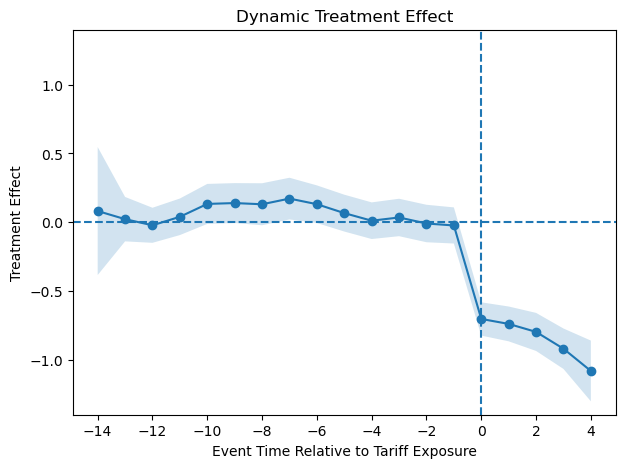


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.0668561220027007, 't_stat': 3.2541766829734815, 'p_value': 0.00767802382231758}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.8484656117947156, 'SE': 0.06890169319335358, 't_stat': -12.31414748275824, 'p_value': 0.0, 'CI_low': -0.9835129304536886, 'CI_high': -0.7134182931357426, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.7469013426061103, 'SE': 0.027449842068032967, 't_stat': -27.20967722710226, 'p_value': 0.0, 'CI_low': -0.8007030330594549, 'CI_high': -0.6930996521527657, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12 -0.0914 0.1045 -0.8749   0.3816        620   
1    2025-03             -11  0.0366 0.1076  0.3397   0.7340        620   
2    2025-03             -10  0.1234 0.1132  1.0897   0.2758        617   
3    202

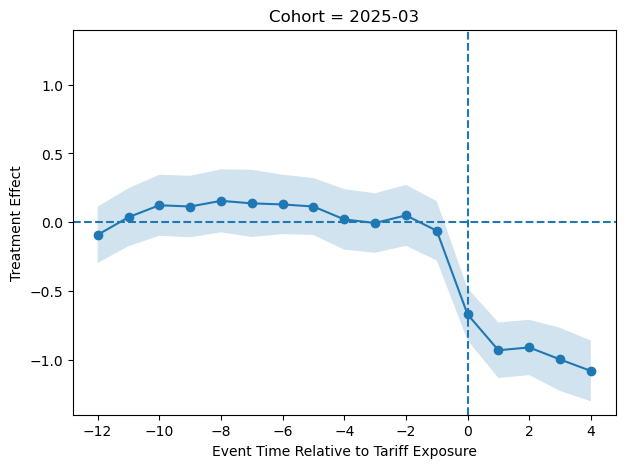

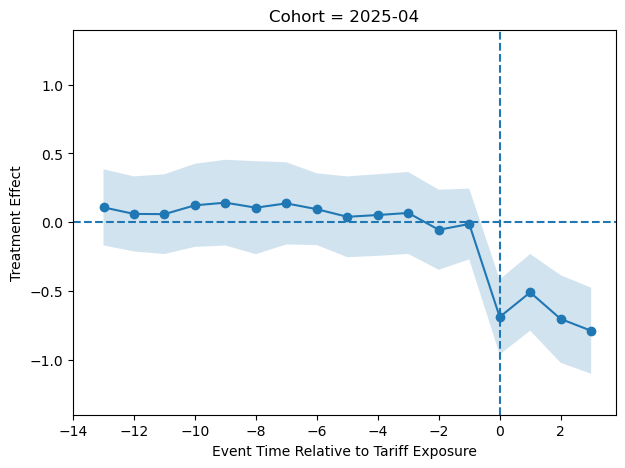

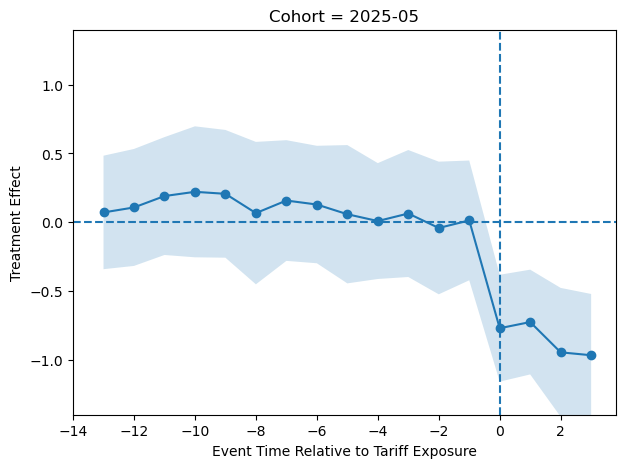

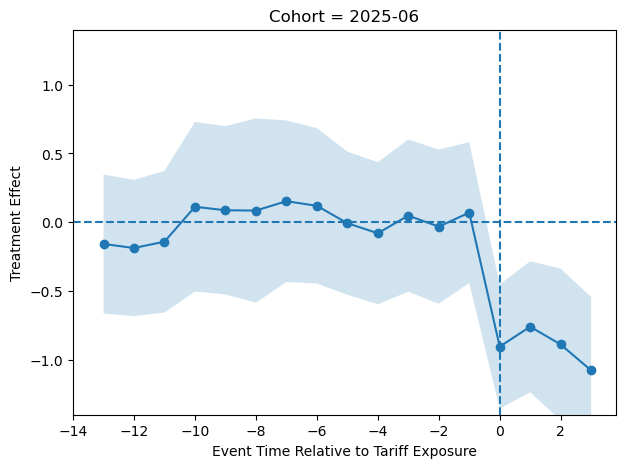

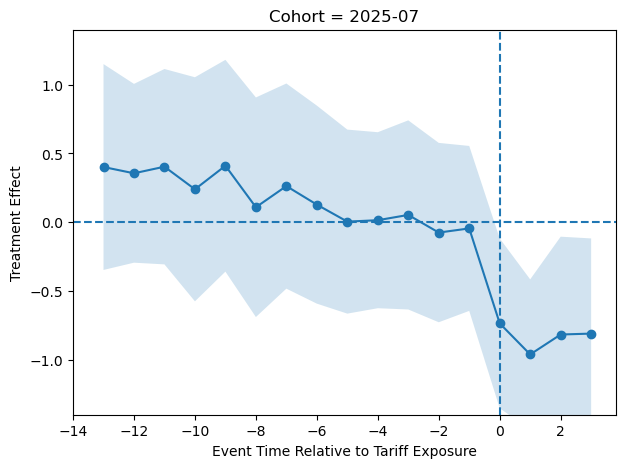

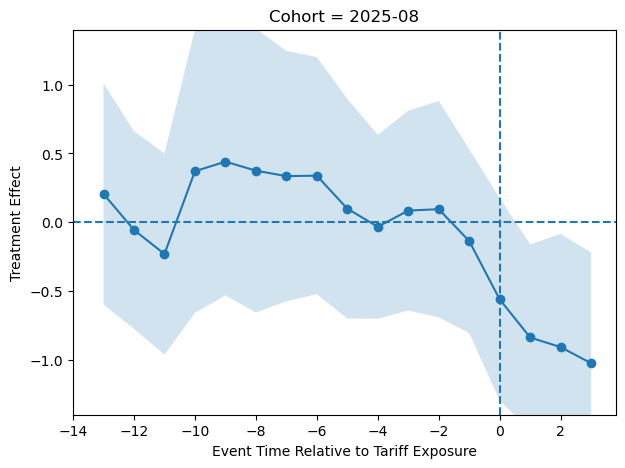

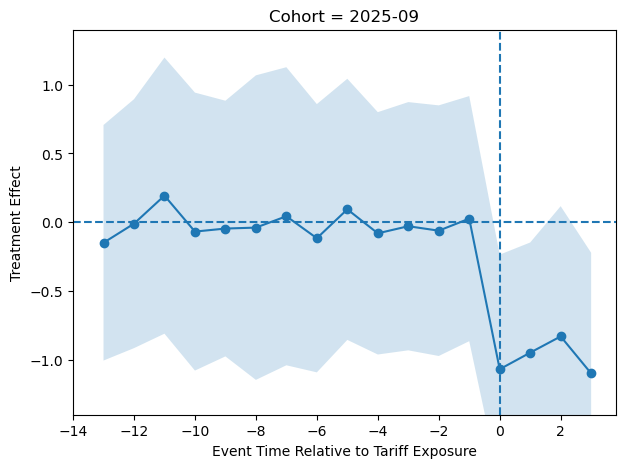

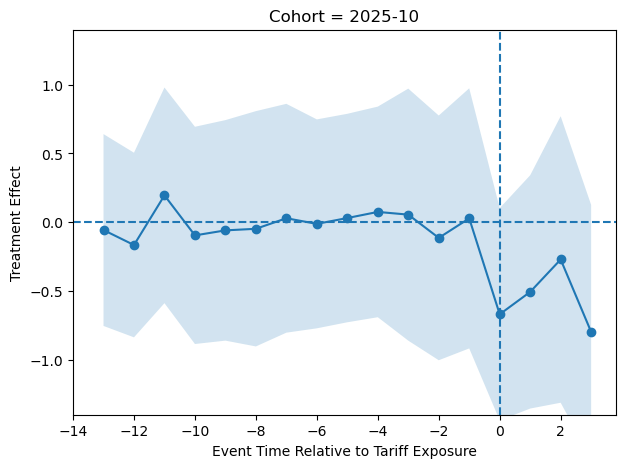

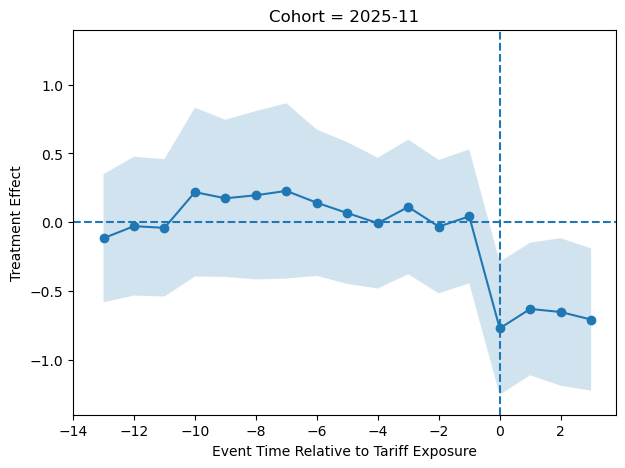

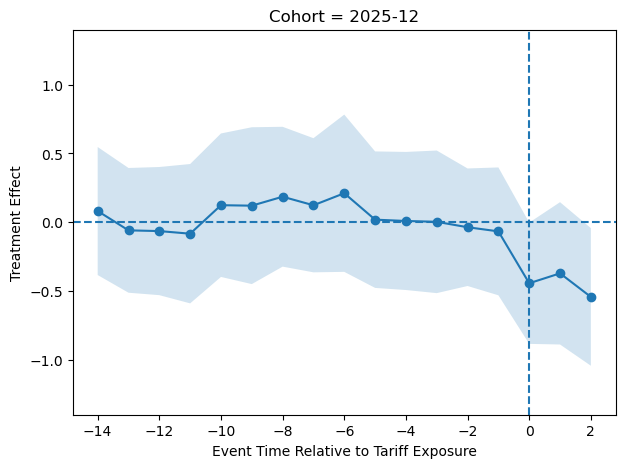

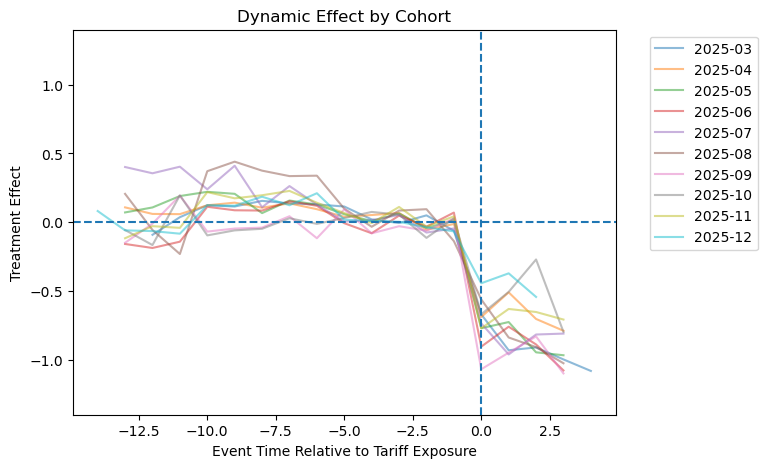


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.9183 0.0689 -13.3368   0.0000 -1.0532  -0.7833          5
1  2025-04 -0.6730 0.0587 -11.4744   0.0000 -0.7880  -0.5581          4
2  2025-05 -0.8526 0.0610 -13.9782   0.0000 -0.9722  -0.7331          4
3  2025-06 -0.9079 0.0653 -13.9045   0.0000 -1.0359  -0.7799          4
4  2025-07 -0.8310 0.0473 -17.5822   0.0000 -0.9236  -0.7383          4
5  2025-08 -0.8336 0.0985  -8.4610   0.0000 -1.0267  -0.6405          4
6  2025-09 -0.9869 0.0615 -16.0461   0.0000 -1.1075  -0.8664          4
7  2025-10 -0.5612 0.1136  -4.9395   0.0000 -0.7839  -0.3385          4
8  2025-11 -0.6909 0.0315 -21.9407   0.0000 -0.7526  -0.6291          4
9  2025-12 -0.4530 0.0497  -9.1088   0.0000 -0.5504  -0.3555          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8373 0.0838  -9.9916   0.000

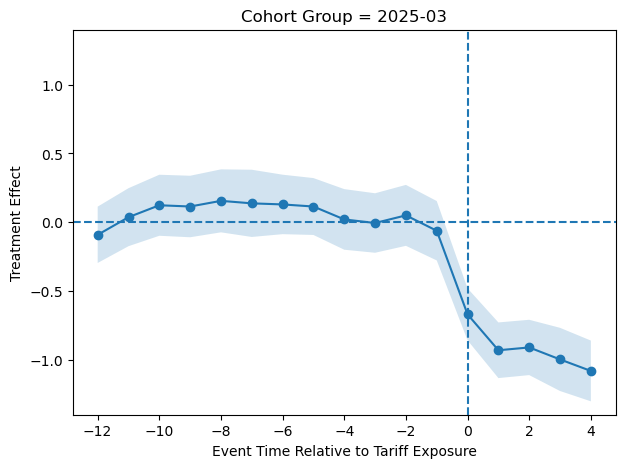

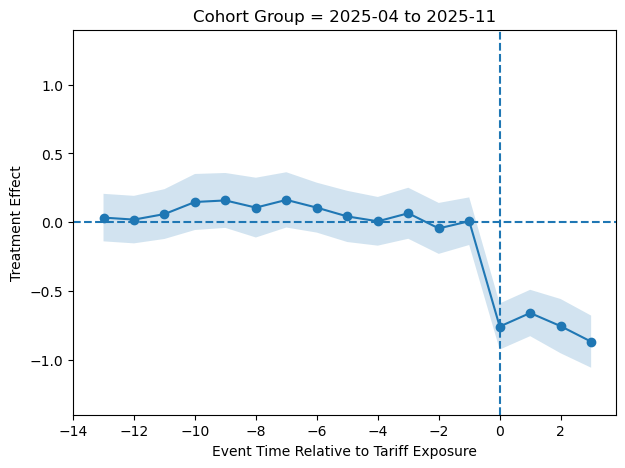

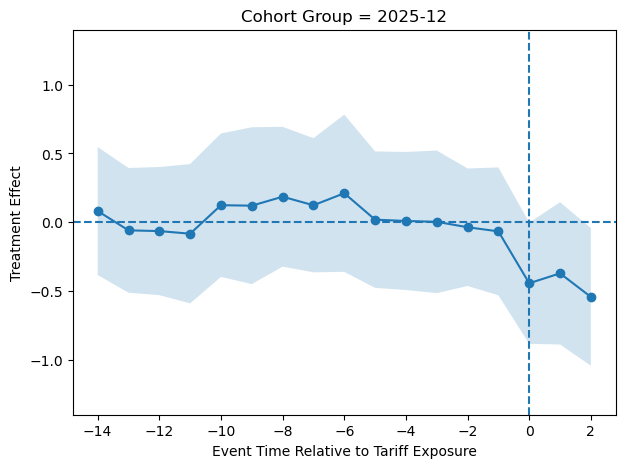

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_high


In [61]:
df_high = df[df["price"]== "high"] 
results_high = run_full_analysis(df_high, ylim=HIGH_YLIM)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 62, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
869257  735999166200003237  2025-03  2023-01          1         -26   
869225  735999166200003237  2025-03  2023-02          1         -25   
869195  735999166200003237  2025-03  2023-03          1         -24   
869196  735999166200003237  2025-03  2023-04          1         -23   
869267  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
617032  735999166200004210  2025-03  2024-08          0          -7   
617080  735999166200004210  2025-03  2024-09          0          -6   
617009  735999166200004210  2025-03  2024-10          0          -5   
617063  735999166200004210  2025-03  2024-11          0          -4   
617003  735999166200004210  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
869257                   1                

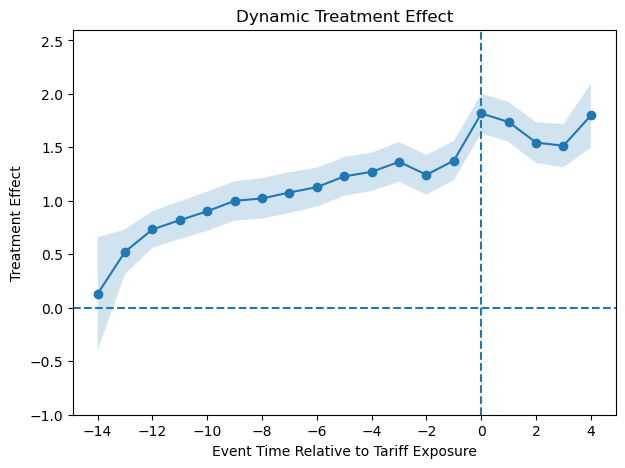


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.097328199356178, 't_stat': 18.142742160847952, 'p_value': 1.5164315760891797e-09}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.6825871713216831, 'SE': 0.06383441464060535, 't_stat': 26.35862145513248, 'p_value': 0.0, 'CI_low': 1.5574717186260967, 'CI_high': 1.8077026240172696, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.6997799584133129, 'SE': 0.0808562440997601, 't_stat': 21.022247290093407, 'p_value': 0.0, 'CI_low': 1.541301719977783, 'CI_high': 1.8582581968488427, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.0742 0.1467  7.3203   0.0000        620   
1    2025-03             -11  1.2445 0.1507  8.2592   0.0000        620   
2    2025-03             -10  1.2019 0.1517  7.9216   0.0000        617   
3    2025-03    

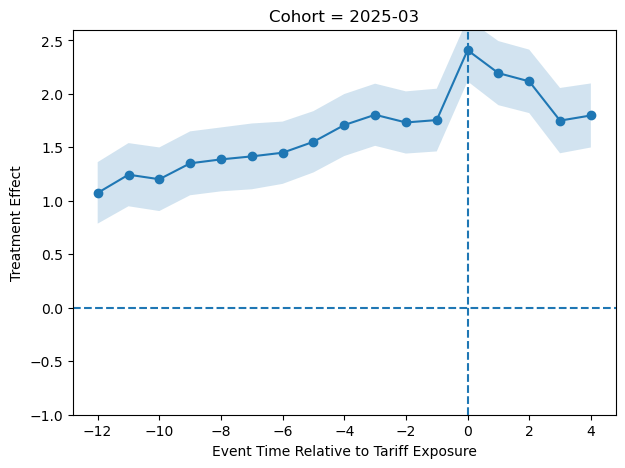

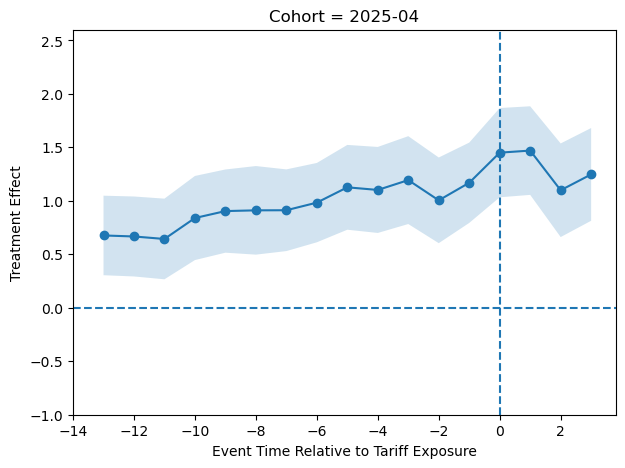

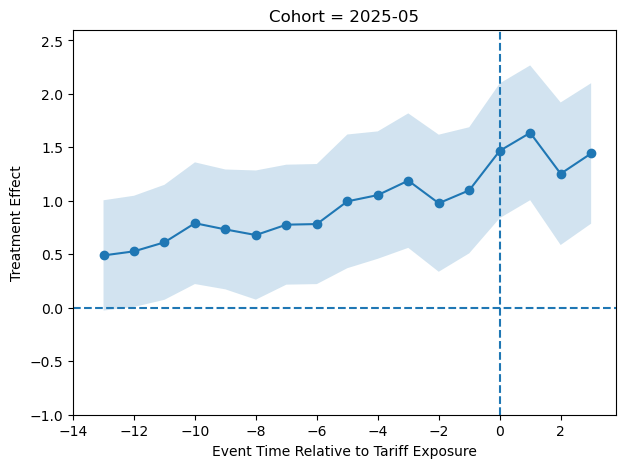

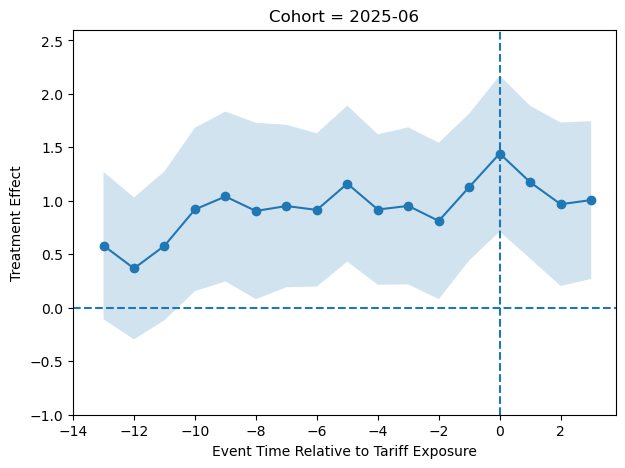

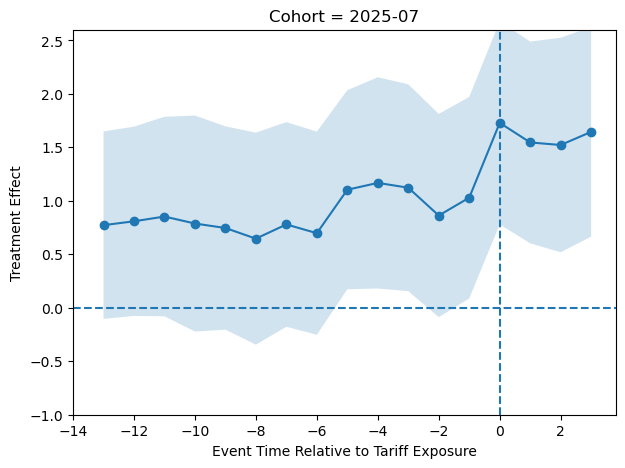

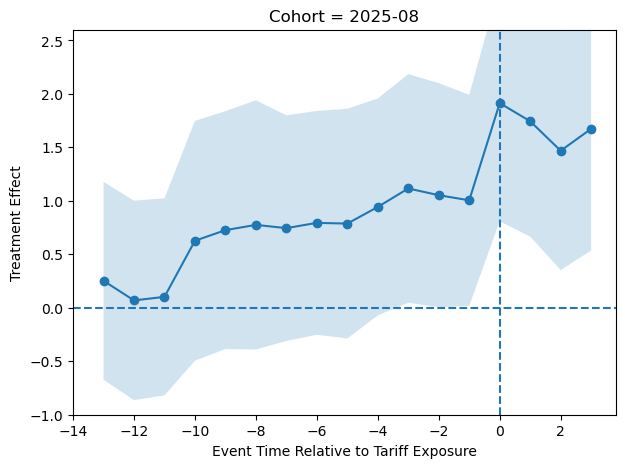

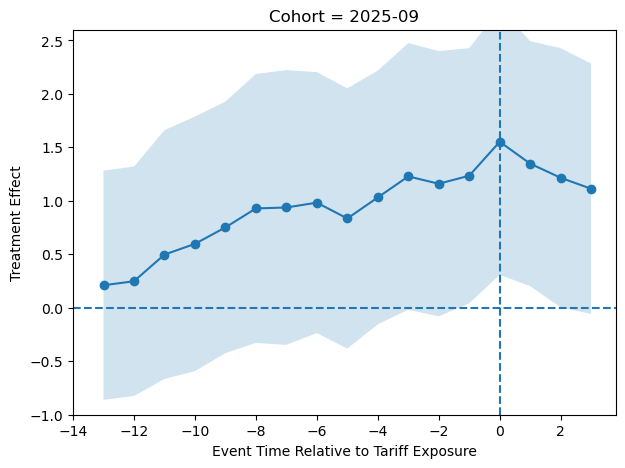

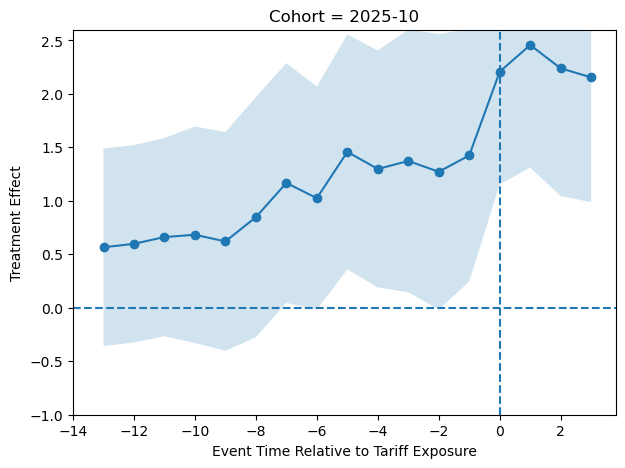

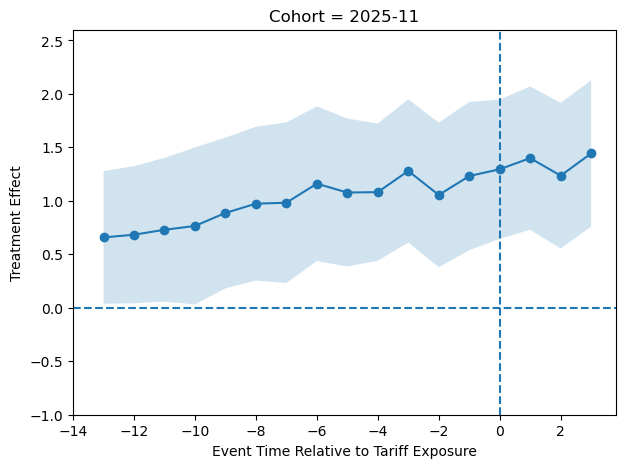

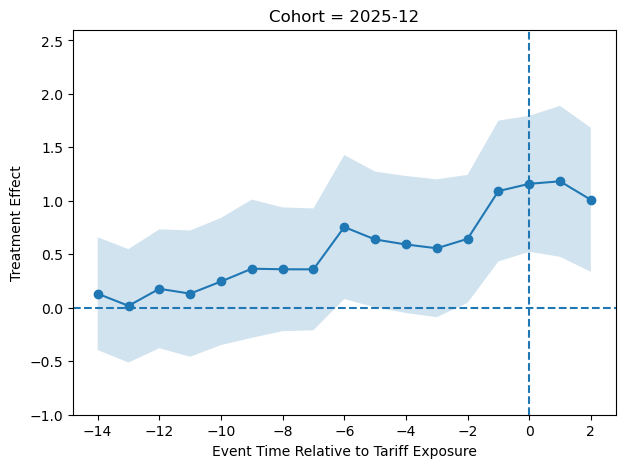

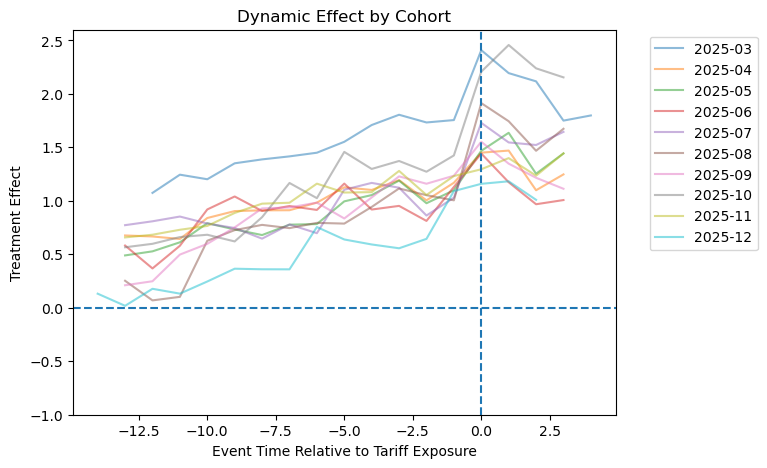


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.0537 0.1239 16.5698   0.0000  1.8108   2.2967          5
1  2025-04 1.3166 0.0883 14.9055   0.0000  1.1435   1.4898          4
2  2025-05 1.4501 0.0783 18.5133   0.0000  1.2966   1.6036          4
3  2025-06 1.1479 0.1078 10.6491   0.0000  0.9366   1.3592          4
4  2025-07 1.6105 0.0476 33.8107   0.0000  1.5172   1.7039          4
5  2025-08 1.6999 0.0922 18.4363   0.0000  1.5192   1.8807          4
6  2025-09 1.3071 0.0948 13.7855   0.0000  1.1212   1.4929          4
7  2025-10 2.2646 0.0665 34.0485   0.0000  2.1342   2.3949          4
8  2025-11 1.3433 0.0476 28.2363   0.0000  1.2501   1.4366          4
9  2025-12 1.1170 0.0542 20.5961   0.0000  1.0107   1.2233          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2401 0.0872 25.6835   0.0000  2.0691   2.4110        

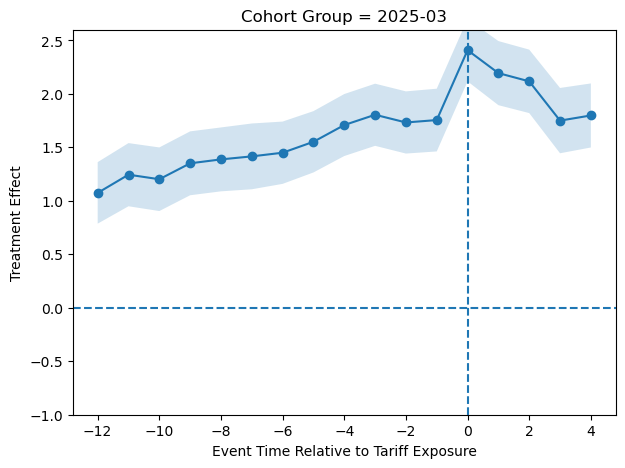

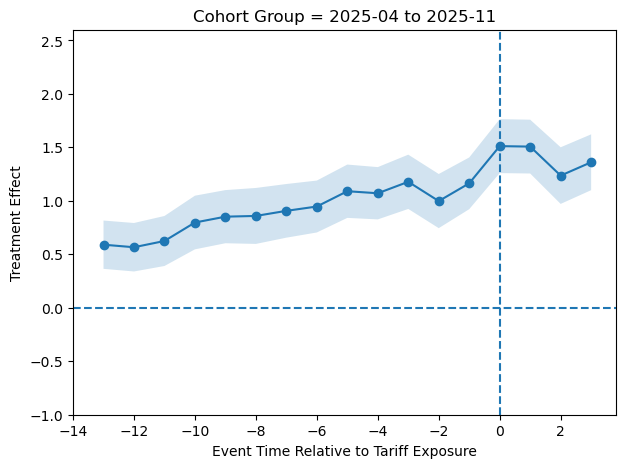

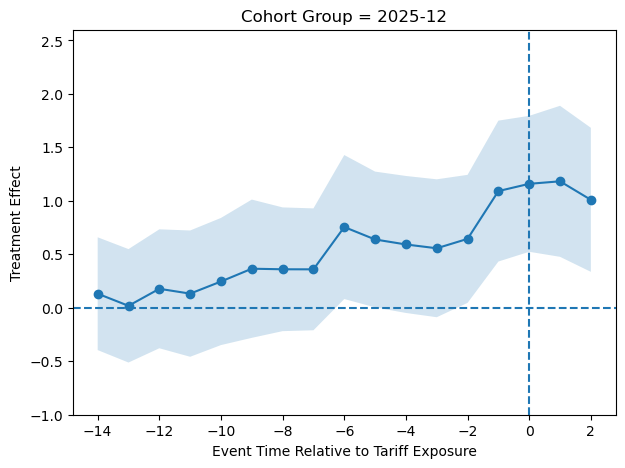

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_all


In [62]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all, ylim=ALL_YLIM)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 63, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
869230  735999166200003237  2025-03  2023-01          1         -26   
869265  735999166200003237  2025-03  2023-02          1         -25   
869248  735999166200003237  2025-03  2023-03          1         -24   
869220  735999166200003237  2025-03  2023-04          1         -23   
869222  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
617069  735999166200004210  2025-03  2024-08          0          -7   
617019  735999166200004210  2025-03  2024-09          0          -6   
617053  735999166200004210  2025-03  2024-10          0          -5   
617011  735999166200004210  2025-03  2024-11          0          -4   
617051  735999166200004210  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
869230                   1                

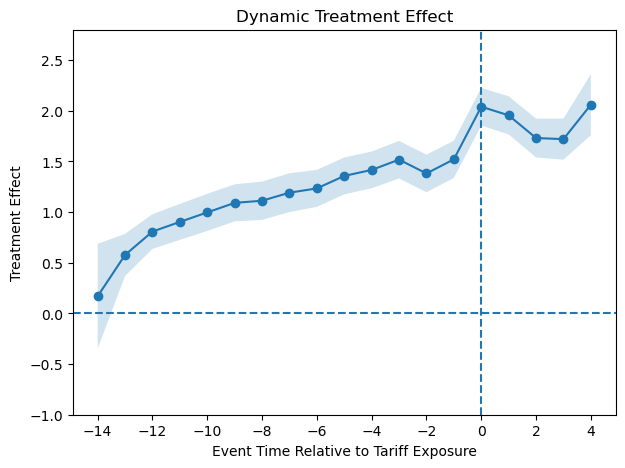


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.2108357884489782, 't_stat': 17.800457565047246, 'p_value': 1.8579949584950835e-09}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.9012404230771398, 'SE': 0.0739279743272126, 't_stat': 25.717469474573452, 'p_value': 0.0, 'CI_low': 1.756341593395803, 'CI_high': 2.0461392527584765, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.908651799272343, 'SE': 0.09227149783491485, 't_stat': 20.685171955127007, 'p_value': 0.0, 'CI_low': 1.7277996635159099, 'CI_high': 2.0895039350287763, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.1850 0.1474  8.0411   0.0000        620   
1    2025-03             -11  1.3604 0.1513  8.9911   0.0000        620   
2    2025-03             -10  1.3405 0.1531  8.7555   0.0000        617   
3    2025-03   

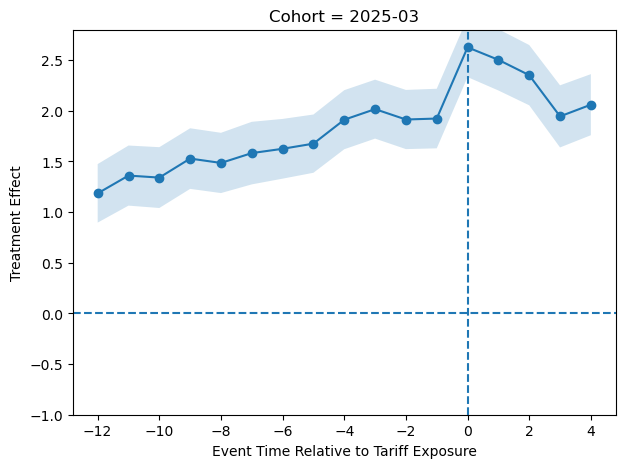

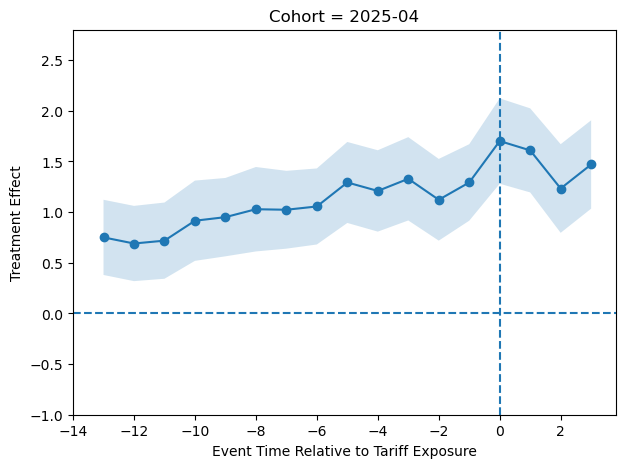

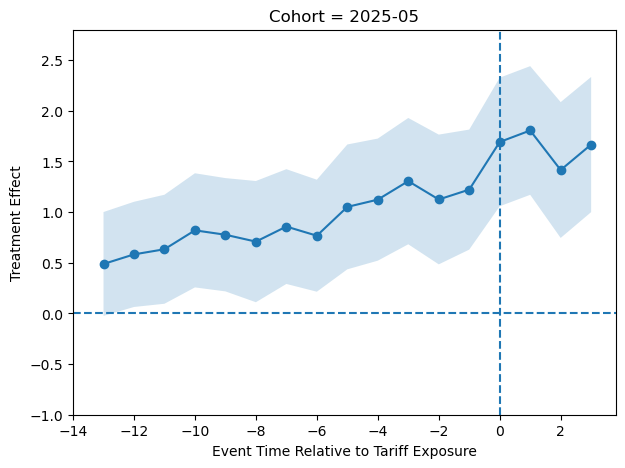

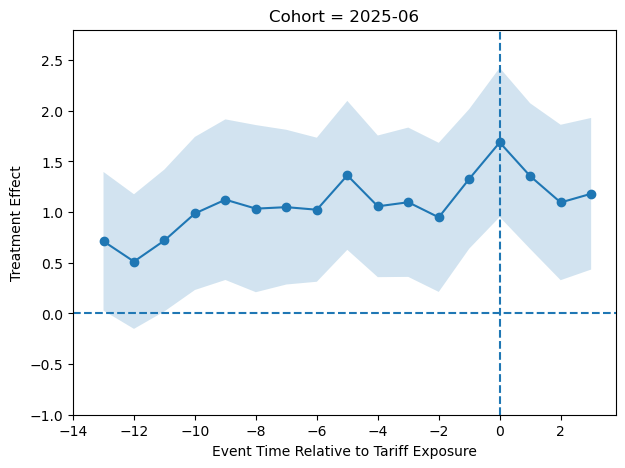

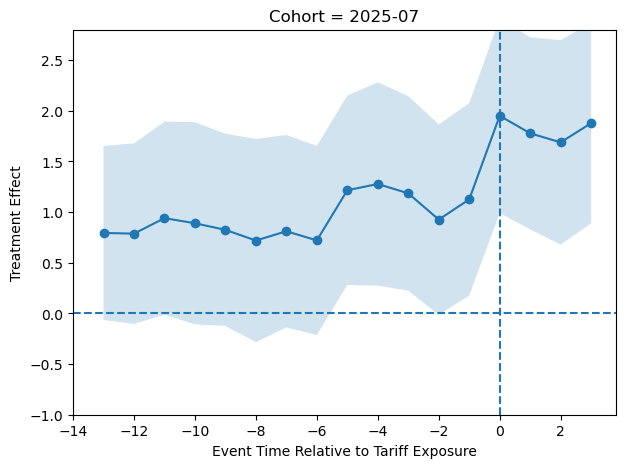

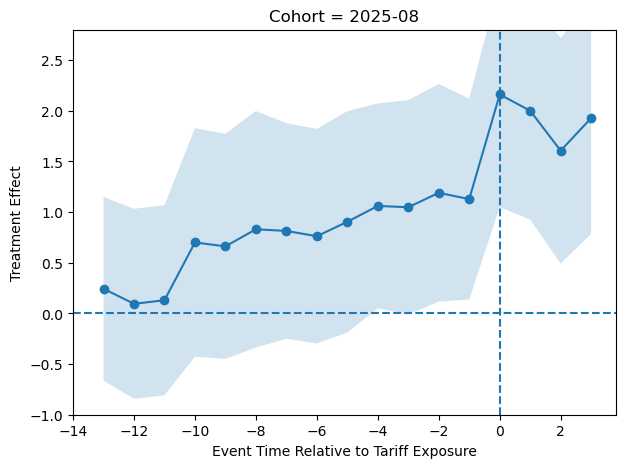

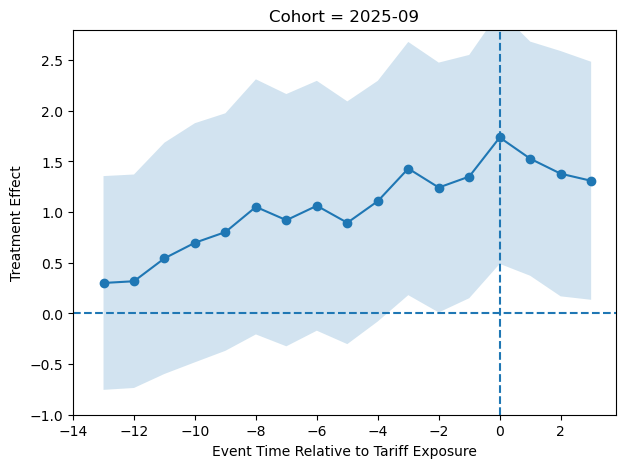

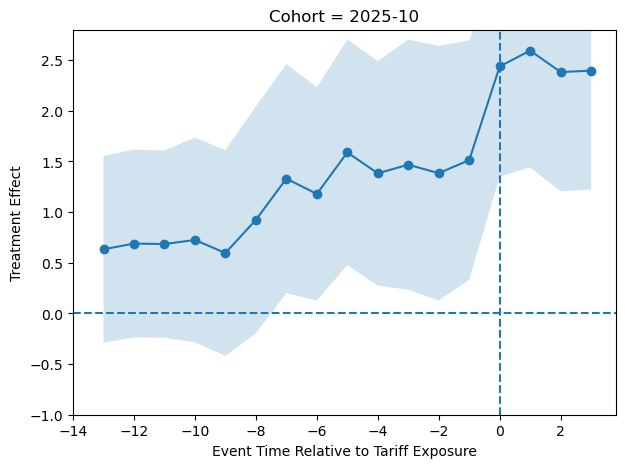

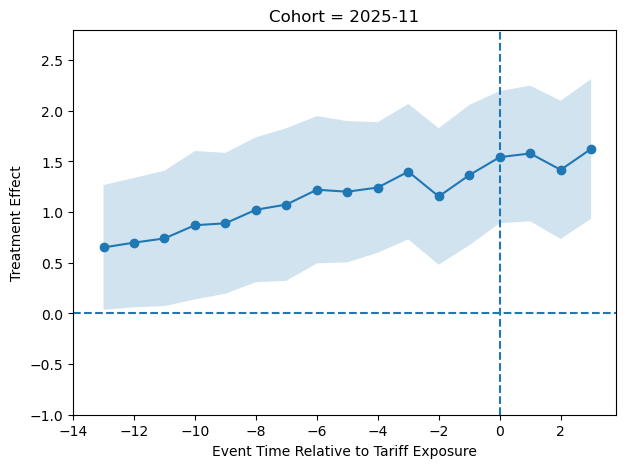

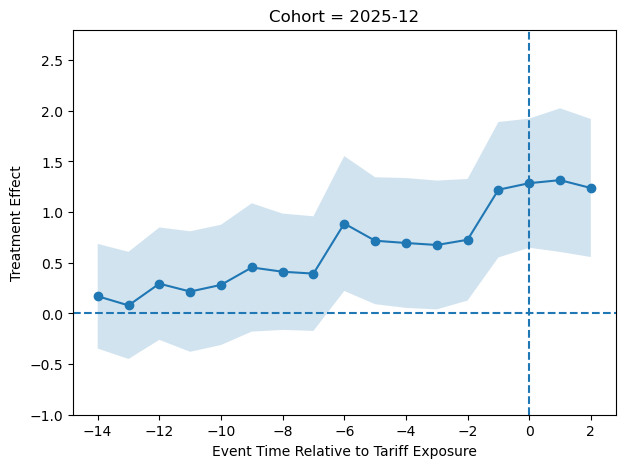

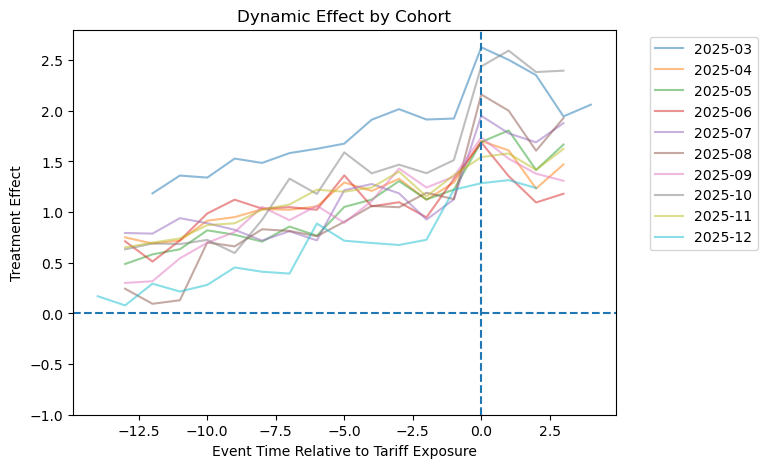


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2971 0.1292 17.7765   0.0000  2.0438   2.5504          5
1  2025-04 1.5033 0.1019 14.7480   0.0000  1.3035   1.7031          4
2  2025-05 1.6449 0.0823 19.9897   0.0000  1.4836   1.8061          4
3  2025-06 1.3296 0.1310 10.1495   0.0000  1.0729   1.5864          4
4  2025-07 1.8236 0.0574 31.7548   0.0000  1.7111   1.9362          4
5  2025-08 1.9238 0.1166 16.5040   0.0000  1.6954   2.1523          4
6  2025-09 1.4879 0.0945 15.7392   0.0000  1.3026   1.6732          4
7  2025-10 2.4526 0.0485 50.5390   0.0000  2.3575   2.5477          4
8  2025-11 1.5405 0.0444 34.6852   0.0000  1.4535   1.6276          4
9  2025-12 1.2795 0.0226 56.5730   0.0000  1.2352   1.3239          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.4935 0.0795 31.3797   0.0000  2.3378   2.6493        

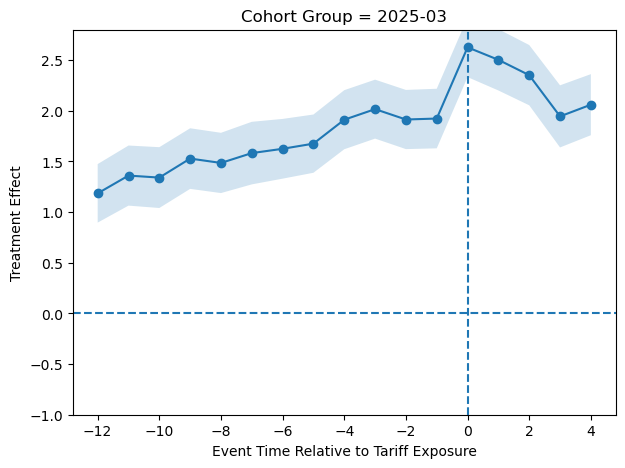

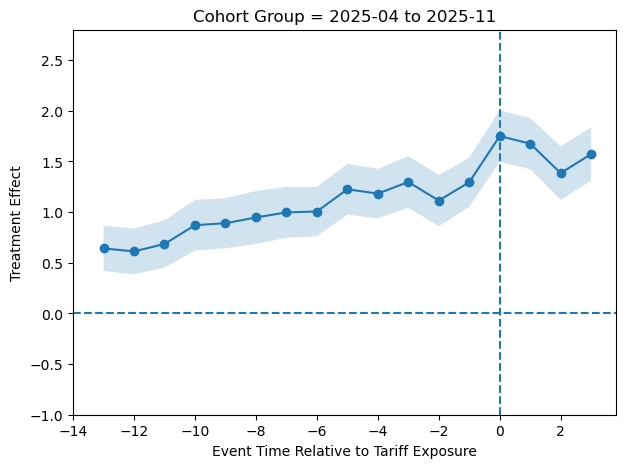

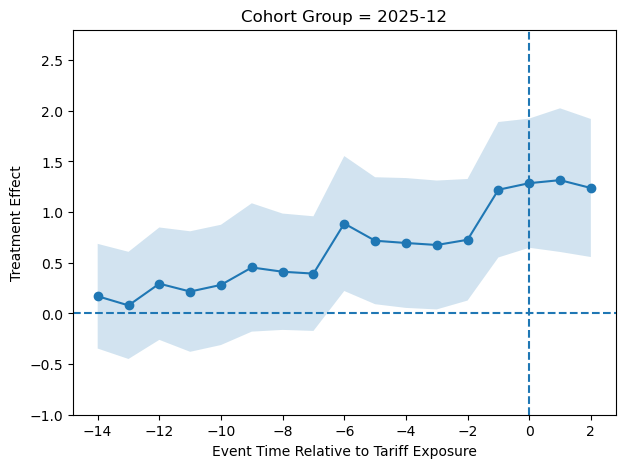

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_low


In [63]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low, ylim=LOW_YLIM)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")

In [64]:
# Change here !!!
match_method = "calendar2_1year"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 64, Finished, Available, Finished, False)

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 65, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
909919  735999166200003237  2025-03  2023-01          1         -26   
909931  735999166200003237  2025-03  2023-02          1         -25   
909903  735999166200003237  2025-03  2023-03          1         -24   
909875  735999166200003237  2025-03  2023-11          1         -16   
909909  735999166200003237  2025-03  2023-12          1         -15   
...                    ...      ...      ...        ...         ...   
805176  735999166200013533  2025-03  2025-01          0          -2   
805223  735999166200013533  2025-03  2025-02          0          -1   
805216  735999166200013533  2025-03  2025-03          0           0   
805244  735999166200013533  2025-03  2025-11          0           8   
805192  735999166200013533  2025-03  2025-12          0           9   

        cohort_event_month  target_month_flag  new_event_time  
909919                   1                

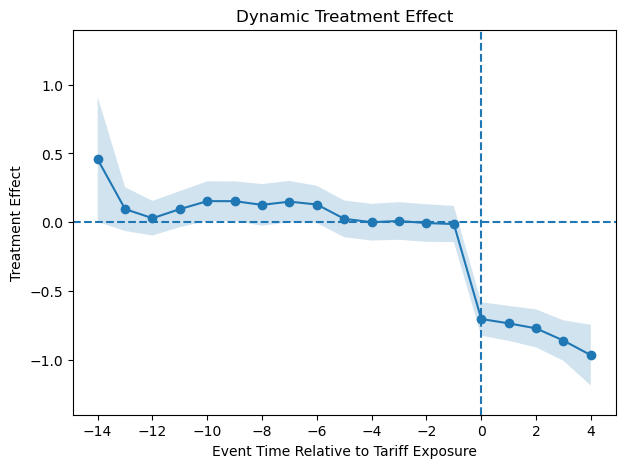


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.07085447452654463, 't_stat': 3.5521254497068497, 'p_value': 0.004535108996613898}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.807808739088052, 'SE': 0.047694899294037606, 't_stat': -16.937004816970795, 'p_value': 0.0, 'CI_low': -0.9012907417043656, 'CI_high': -0.7143267364717383, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.7370826387466982, 'SE': 0.01970328026375853, 't_stat': -37.4091333463119, 'p_value': 0.0, 'CI_low': -0.7757010680636649, 'CI_high': -0.6984642094297315, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12 -0.0425 0.1030 -0.4130   0.6796        620   
1    2025-03             -11  0.1051 0.1063  0.9884   0.3229        620   
2    2025-03             -10  0.1053 0.1122  0.9385   0.3480        617   
3    20

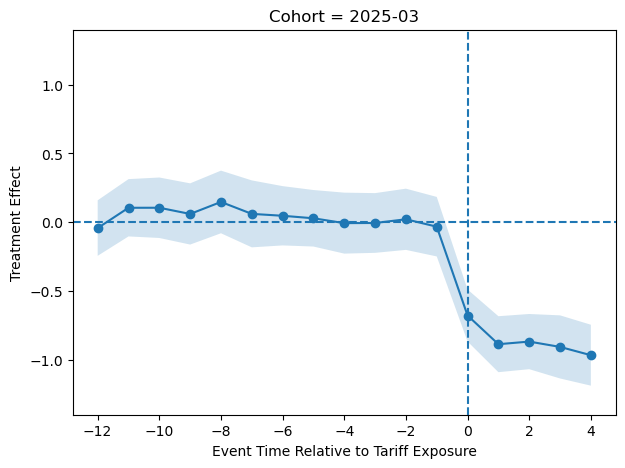

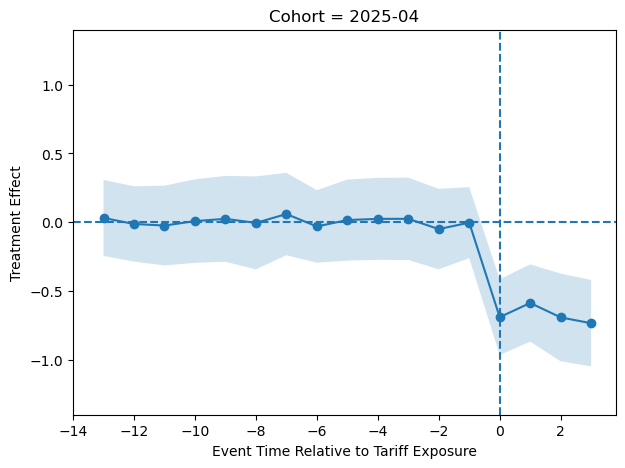

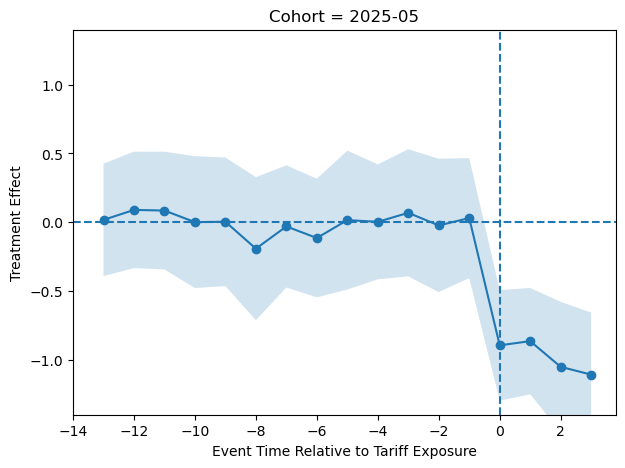

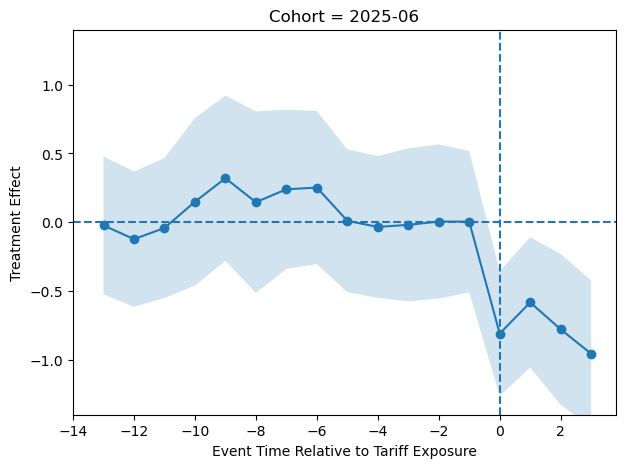

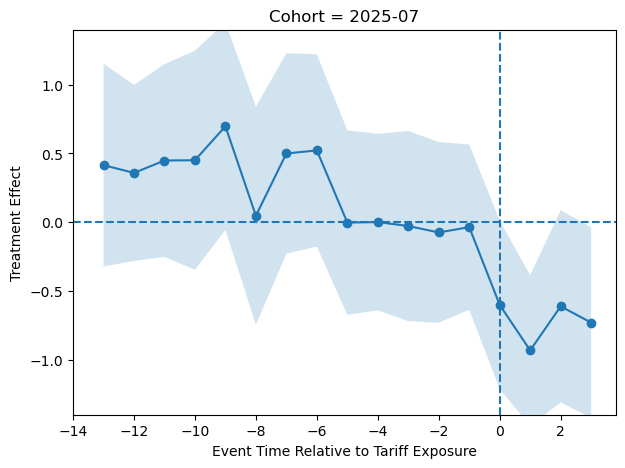

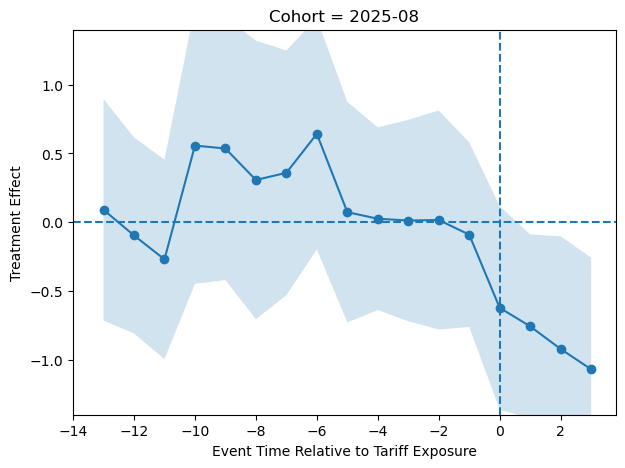

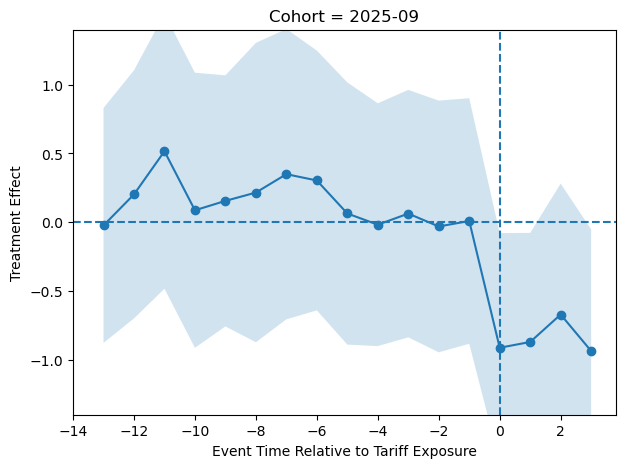

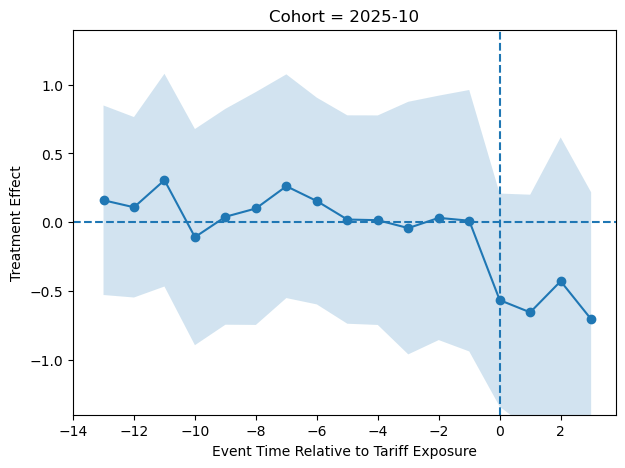

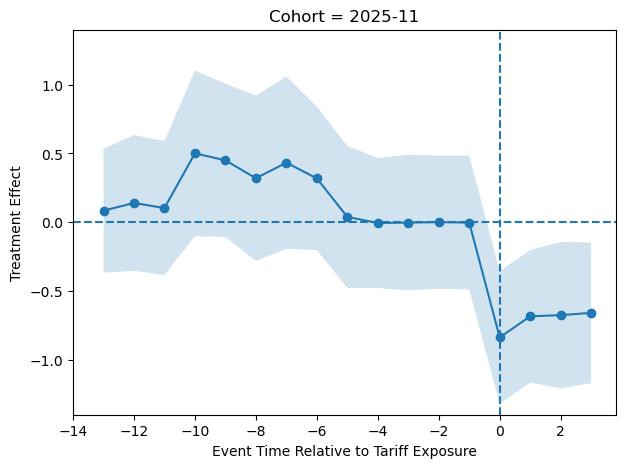

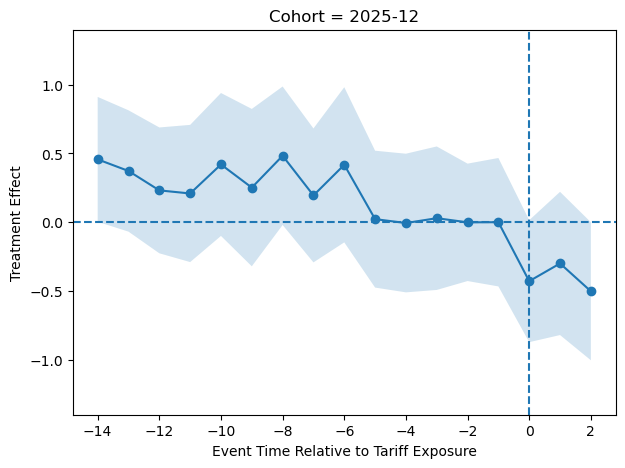

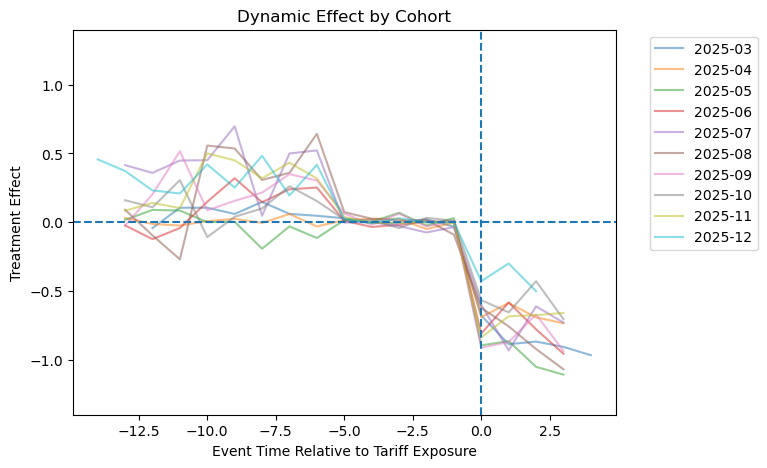


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8615 0.0487 -17.7016   0.0000 -0.9569  -0.7661          5
1  2025-04 -0.6761 0.0313 -21.5930   0.0000 -0.7375  -0.6148          4
2  2025-05 -0.9800 0.0592 -16.5589   0.0000 -1.0961  -0.8640          4
3  2025-06 -0.7822 0.0768 -10.1804   0.0000 -0.9327  -0.6316          4
4  2025-07 -0.7188 0.0767  -9.3664   0.0000 -0.8692  -0.5684          4
5  2025-08 -0.8429 0.0972  -8.6690   0.0000 -1.0335  -0.6523          4
6  2025-09 -0.8479 0.0605 -14.0201   0.0000 -0.9664  -0.7294          4
7  2025-10 -0.5891 0.0606  -9.7166   0.0000 -0.7079  -0.4702          4
8  2025-11 -0.7143 0.0416 -17.1751   0.0000 -0.7958  -0.6328          4
9  2025-12 -0.4102 0.0591  -6.9377   0.0000 -0.5261  -0.2943          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8112 0.0666 -12.1832   0.000

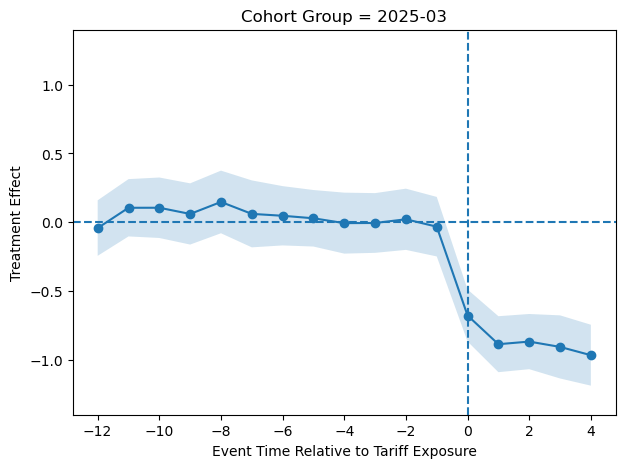

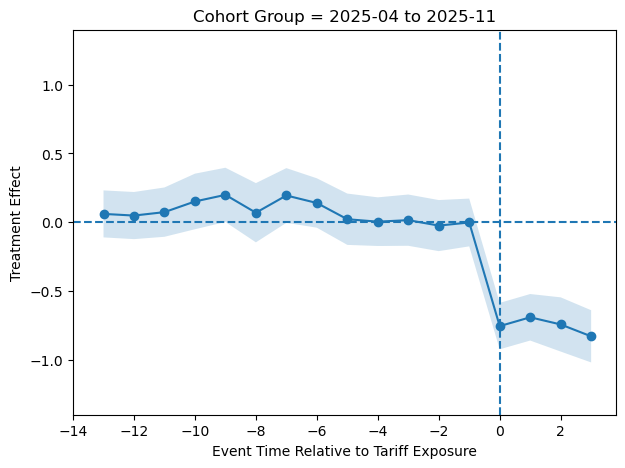

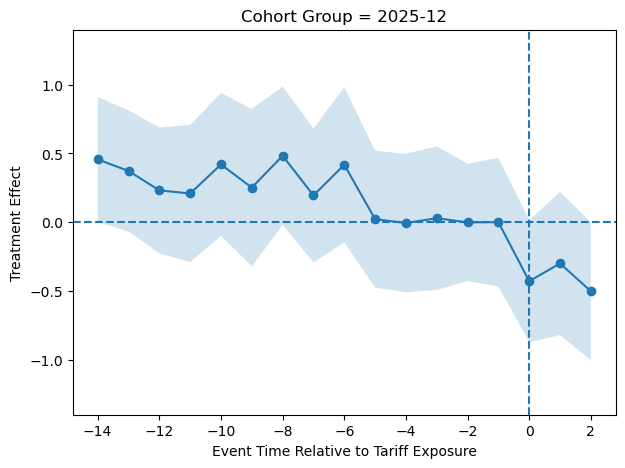

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high


In [65]:
df_high = df[df["price"]== "high"] 
results_high = run_full_analysis(df_high, ylim=HIGH_YLIM)

save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 66, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
909915  735999166200003237  2025-03  2023-01          1         -26   
909883  735999166200003237  2025-03  2023-02          1         -25   
909853  735999166200003237  2025-03  2023-03          1         -24   
909854  735999166200003237  2025-03  2023-04          1         -23   
909925  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
207563  735999166200012017  2025-03  2024-08          0          -7   
207631  735999166200012017  2025-03  2024-09          0          -6   
207583  735999166200012017  2025-03  2024-10          0          -5   
207665  735999166200012017  2025-03  2024-11          0          -4   
207599  735999166200012017  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
909915                   1                

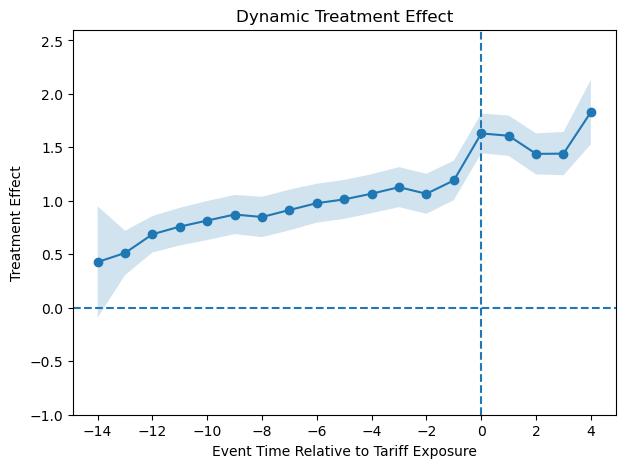


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.9451487822236938, 't_stat': 21.19425742828691, 'p_value': 2.866135810825379e-10}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.589832064700883, 'SE': 0.07220198438717475, 't_stat': 22.019229501721078, 'p_value': 0.0, 'CI_low': 1.4483161753020206, 'CI_high': 1.7313479540997454, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.5594587914536406, 'SE': 0.06037798547662577, 't_stat': 25.828268020922238, 'p_value': 0.0, 'CI_low': 1.441117939919454, 'CI_high': 1.6777996429878272, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.0239 0.1459  7.0197   0.0000        620   
1    2025-03             -11  1.1711 0.1503  7.7910   0.0000        620   
2    2025-03             -10  1.1020 0.1511  7.2910   0.0000        617   
3    2025-03    

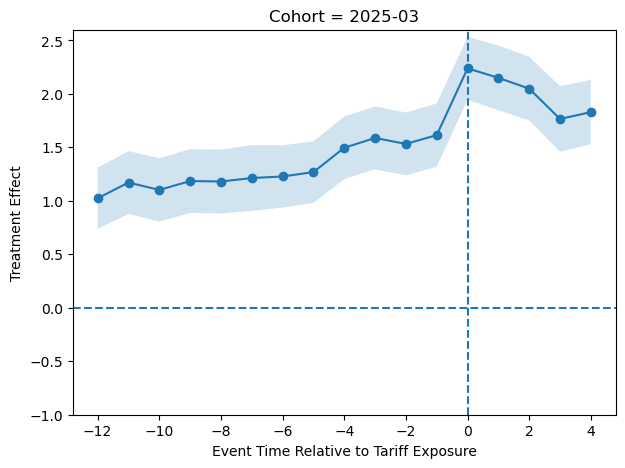

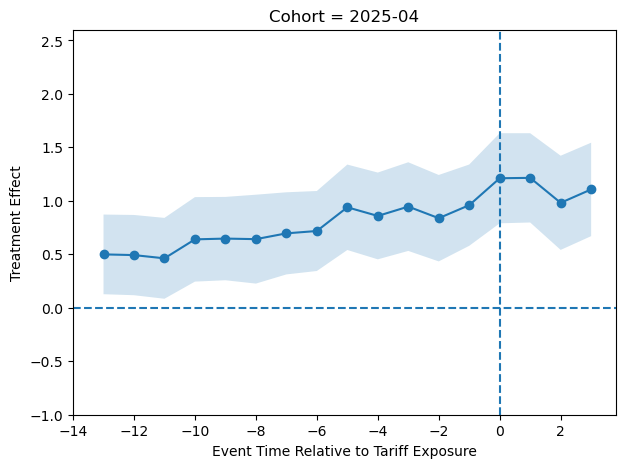

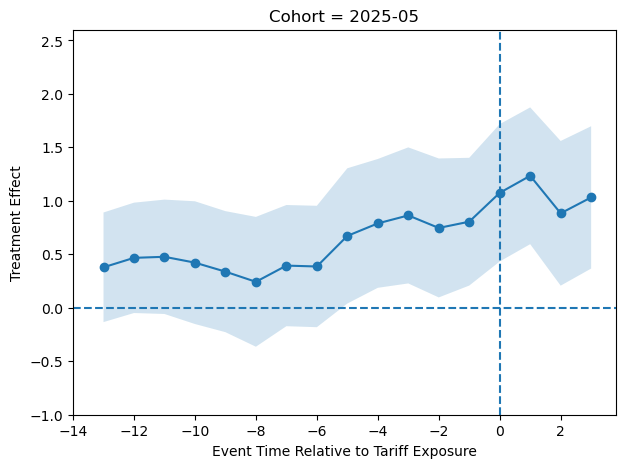

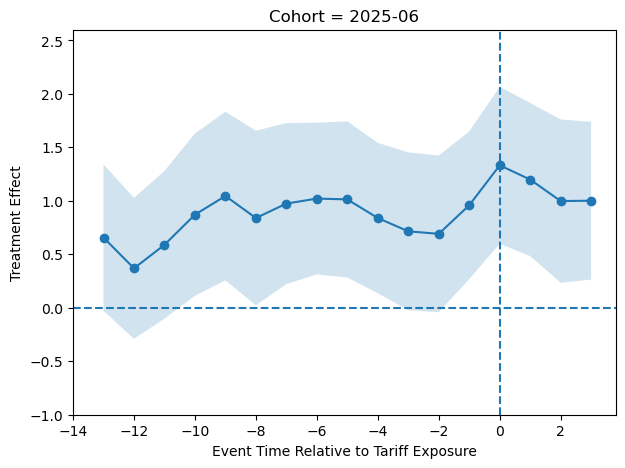

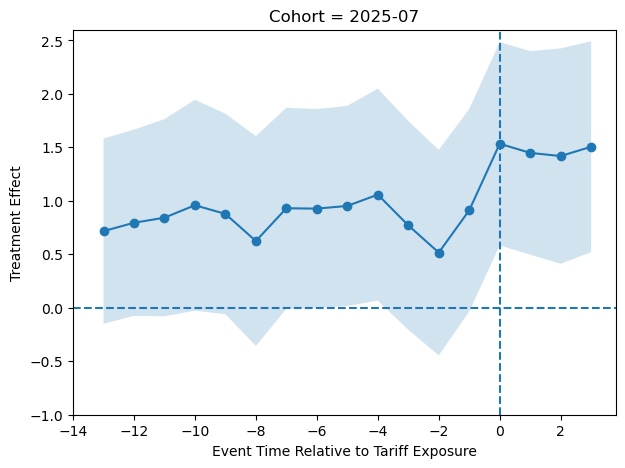

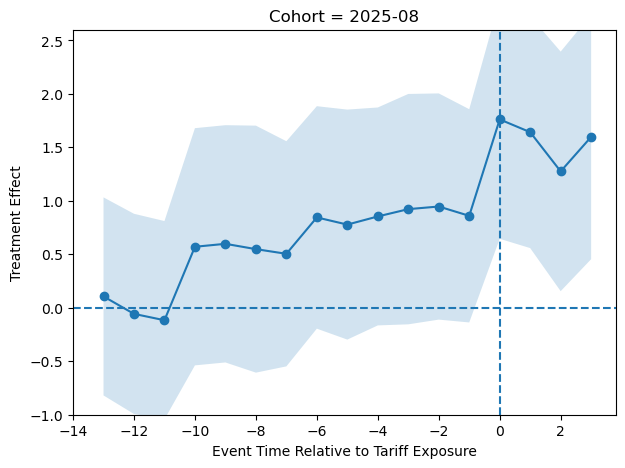

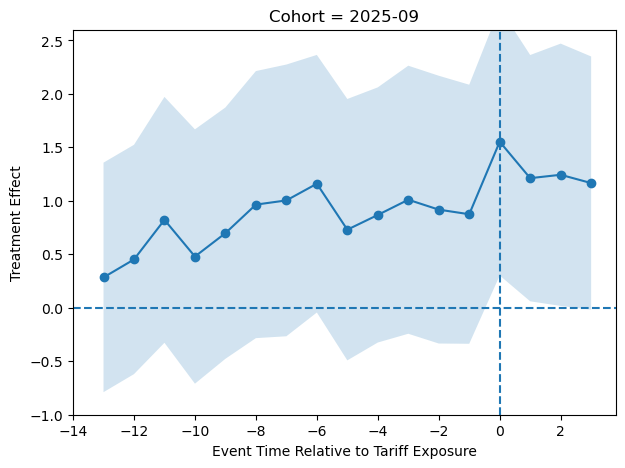

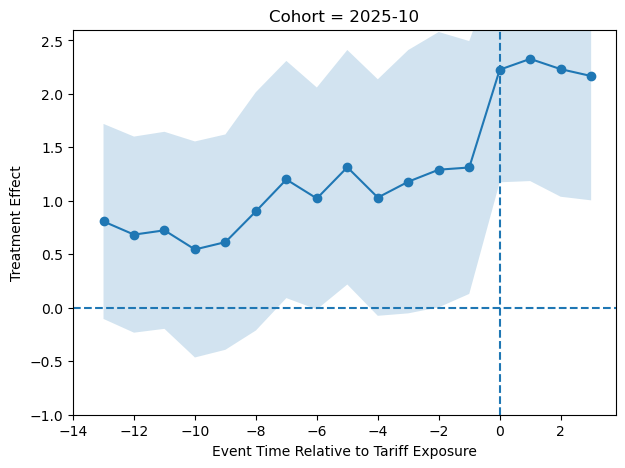

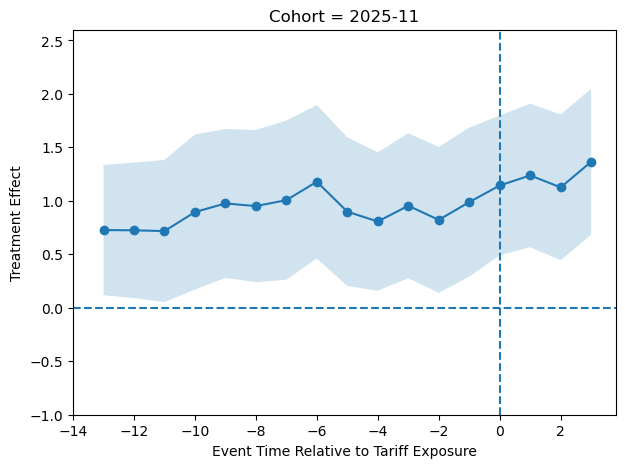

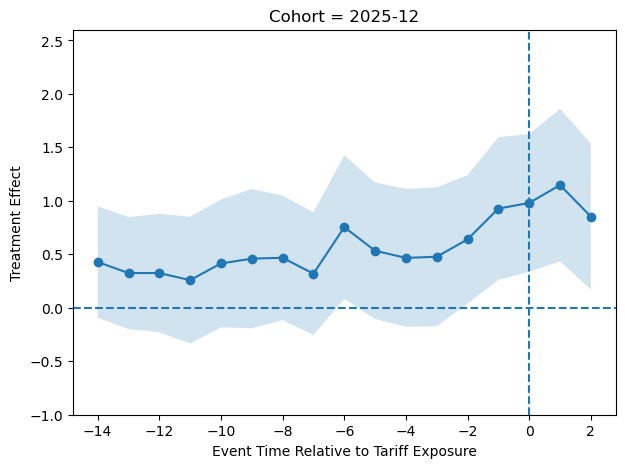

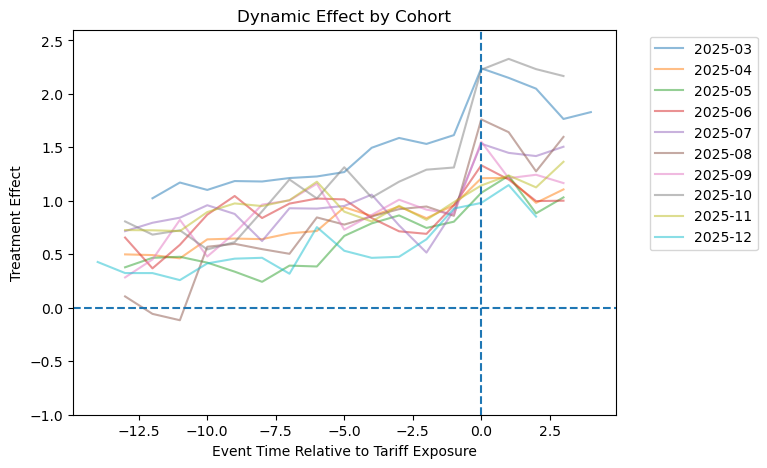


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.0066 0.0910 22.0419   0.0000  1.8282   2.1850          5
1  2025-04 1.1286 0.0551 20.4940   0.0000  1.0206   1.2365          4
2  2025-05 1.0561 0.0722 14.6291   0.0000  0.9146   1.1976          4
3  2025-06 1.1326 0.0815 13.8982   0.0000  0.9728   1.2923          4
4  2025-07 1.4767 0.0263 56.1170   0.0000  1.4251   1.5283          4
5  2025-08 1.5692 0.1038 15.1110   0.0000  1.3656   1.7727          4
6  2025-09 1.2936 0.0879 14.7249   0.0000  1.1215   1.4658          4
7  2025-10 2.2381 0.0332 67.4932   0.0000  2.1731   2.3030          4
8  2025-11 1.2181 0.0548 22.2296   0.0000  1.1107   1.3255          4
9  2025-12 0.9936 0.0853 11.6484   0.0000  0.8264   1.1608          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.1459 0.0549 39.1083   0.0000  2.0384   2.2535        

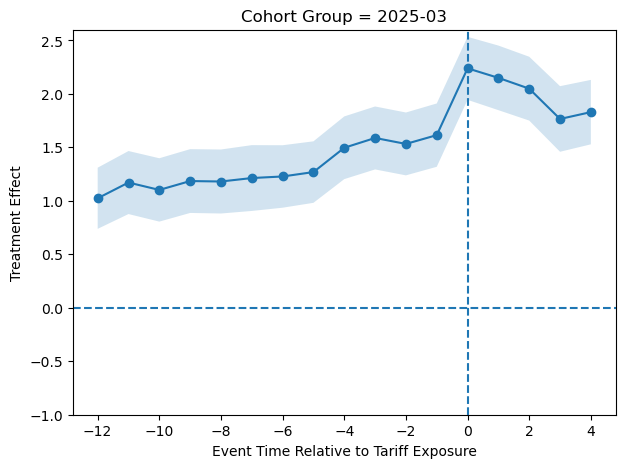

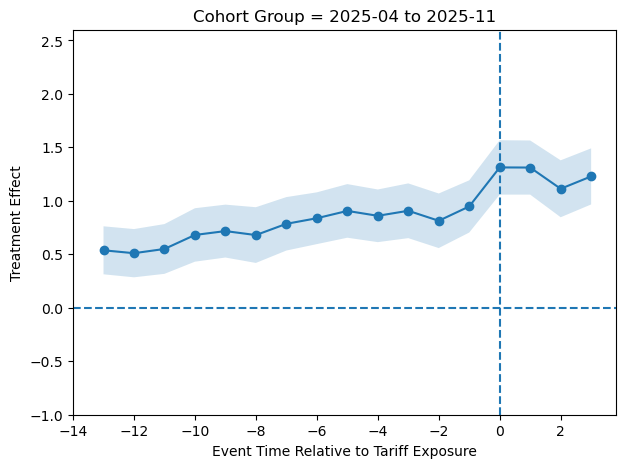

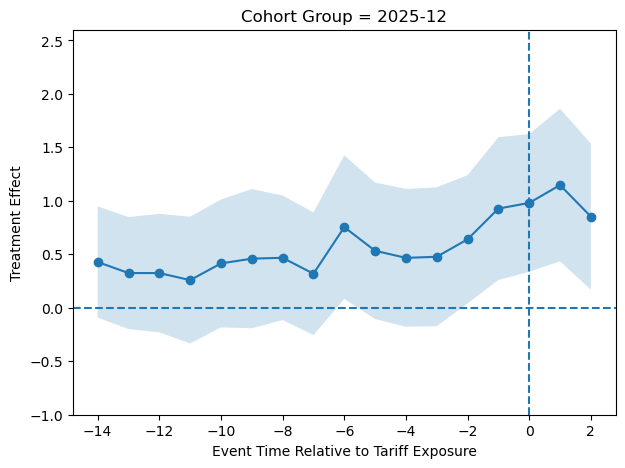

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_1year_all


In [66]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all, ylim=ALL_YLIM)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 67, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
909888  735999166200003237  2025-03  2023-01          1         -26   
909923  735999166200003237  2025-03  2023-02          1         -25   
909906  735999166200003237  2025-03  2023-03          1         -24   
909878  735999166200003237  2025-03  2023-04          1         -23   
909880  735999166200003237  2025-03  2023-05          1         -22   
...                    ...      ...      ...        ...         ...   
207491  735999166200012017  2025-03  2024-08          0          -7   
207613  735999166200012017  2025-03  2024-09          0          -6   
207587  735999166200012017  2025-03  2024-10          0          -5   
207607  735999166200012017  2025-03  2024-11          0          -4   
207507  735999166200012017  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
909888                   1                

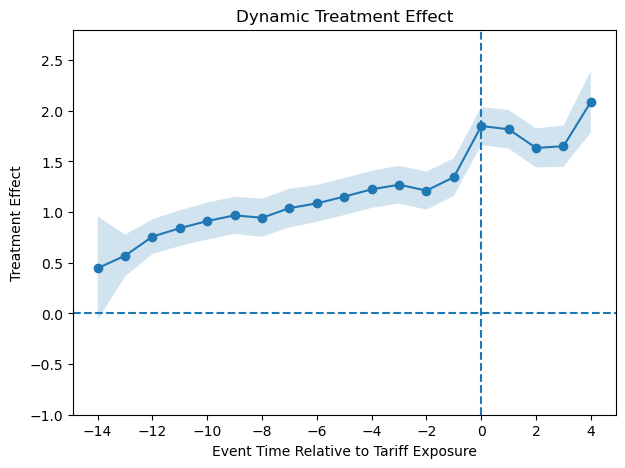


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.0628055441375417, 't_stat': 20.120210287871, 'p_value': 5.0115087126687e-10}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.807807919014857, 'SE': 0.08245892092379783, 't_stat': 21.923739708957548, 'p_value': 0.0, 'CI_low': 1.6461884340042132, 'CI_high': 1.9694274040255009, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.7667311144295874, 'SE': 0.06730720128985793, 't_stat': 26.248768045207733, 'p_value': 0.0, 'CI_low': 1.6348089999014659, 'CI_high': 1.898653228957709, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.1388 0.1464  7.7769   0.0000        620   
1    2025-03             -11  1.2752 0.1509  8.4482   0.0000        620   
2    2025-03             -10  1.2599 0.1526  8.2559   0.0000        617   
3    2025-03        

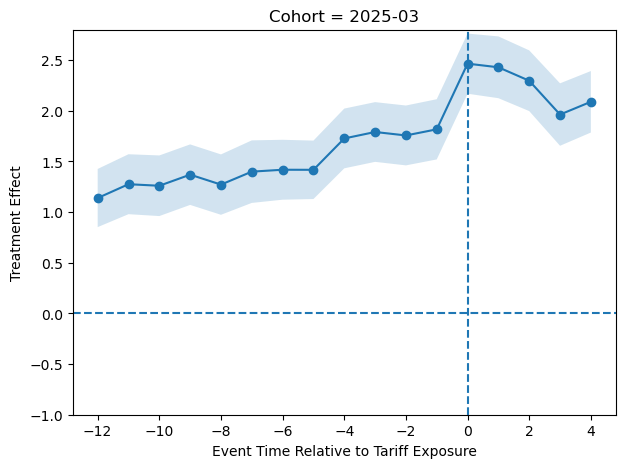

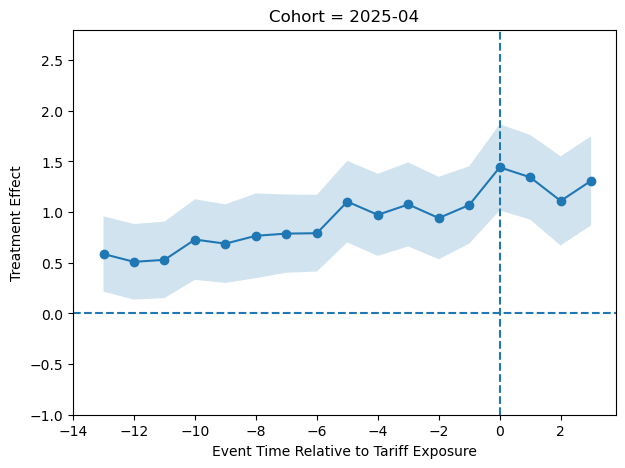

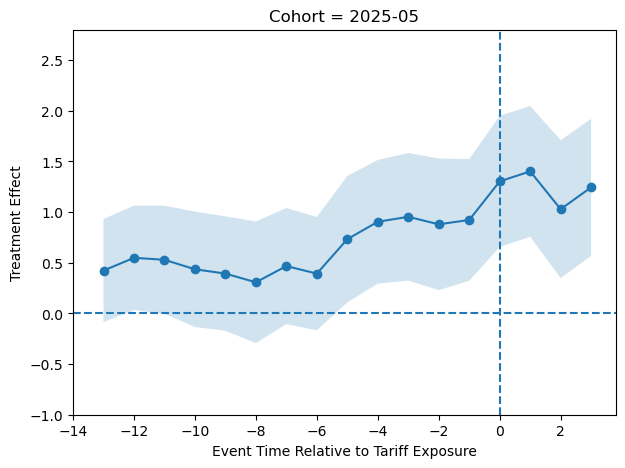

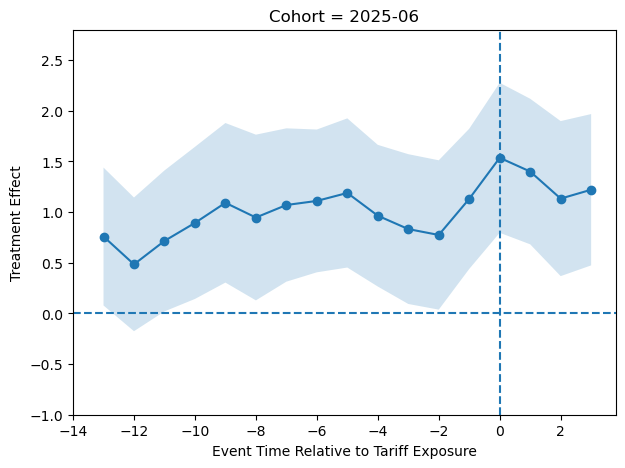

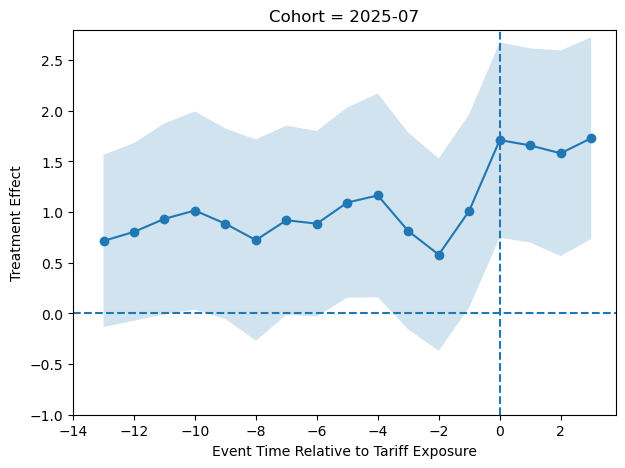

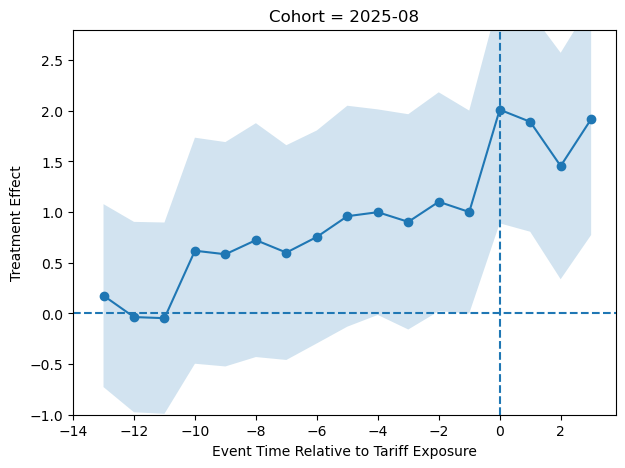

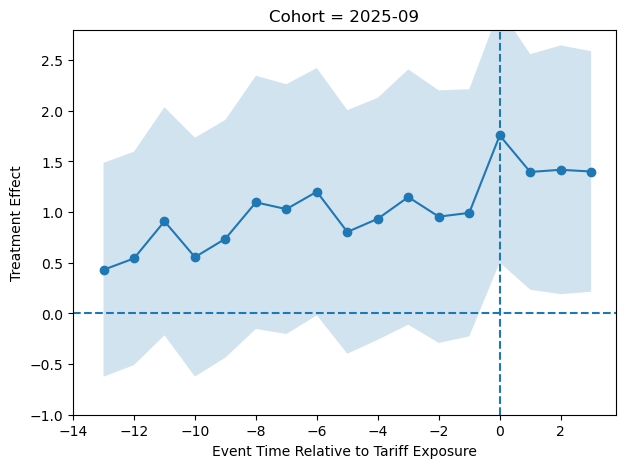

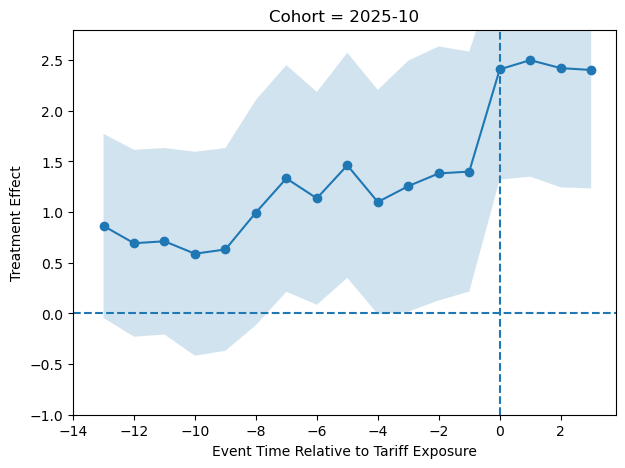

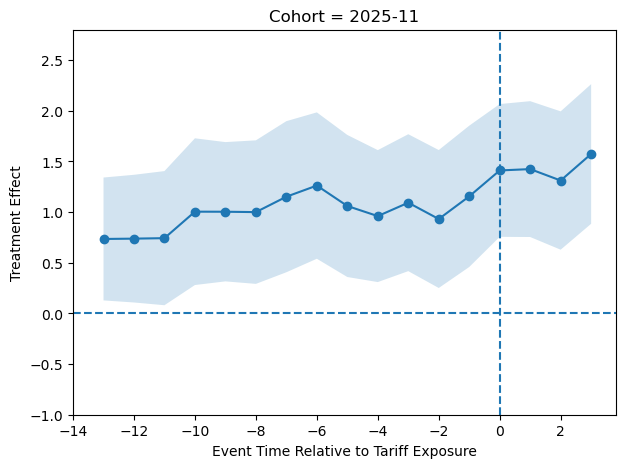

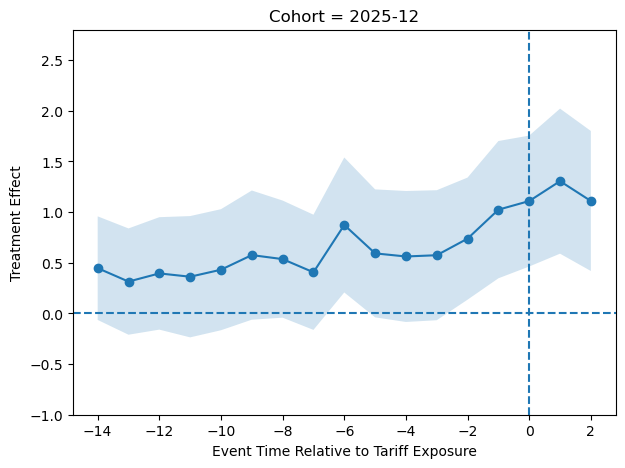

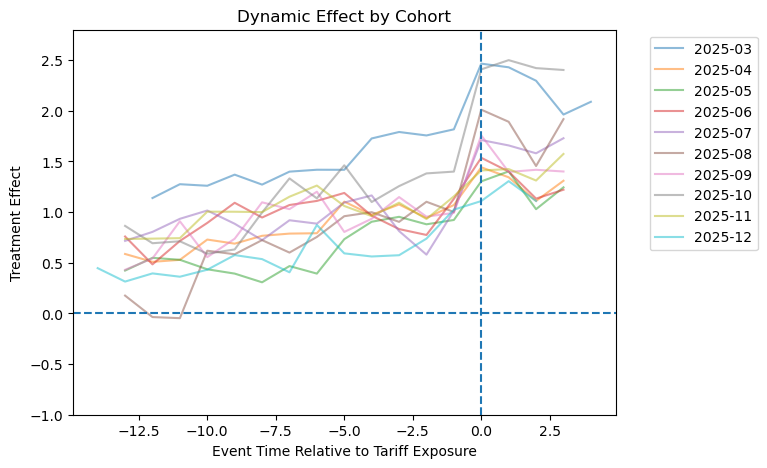


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2485 0.0972  23.1233   0.0000  2.0579   2.4390          5
1  2025-04 1.3013 0.0696  18.6912   0.0000  1.1649   1.4378          4
2  2025-05 1.2445 0.0789  15.7714   0.0000  1.0898   1.3991          4
3  2025-06 1.3225 0.0903  14.6465   0.0000  1.1455   1.4995          4
4  2025-07 1.6696 0.0334  50.0416   0.0000  1.6042   1.7350          4
5  2025-08 1.8186 0.1240  14.6705   0.0000  1.5757   2.0616          4
6  2025-09 1.4927 0.0881  16.9462   0.0000  1.3201   1.6654          4
7  2025-10 2.4331 0.0226 107.8477   0.0000  2.3888   2.4773          4
8  2025-11 1.4301 0.0541  26.4432   0.0000  1.3241   1.5362          4
9  2025-12 1.1746 0.0654  17.9674   0.0000  1.0465   1.3028          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.3969 0.0513 46.7345   0.0000  2.2964   2.4

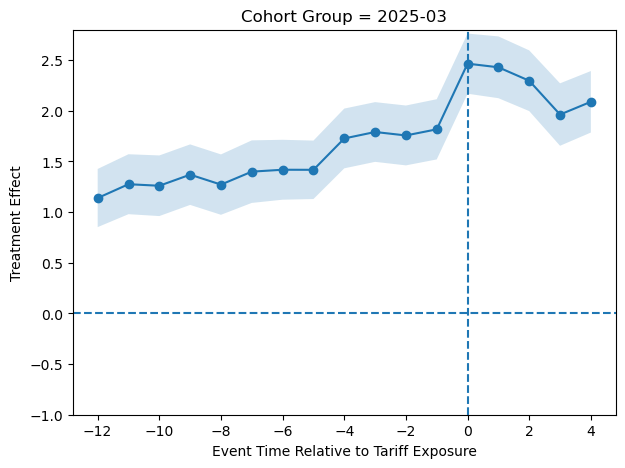

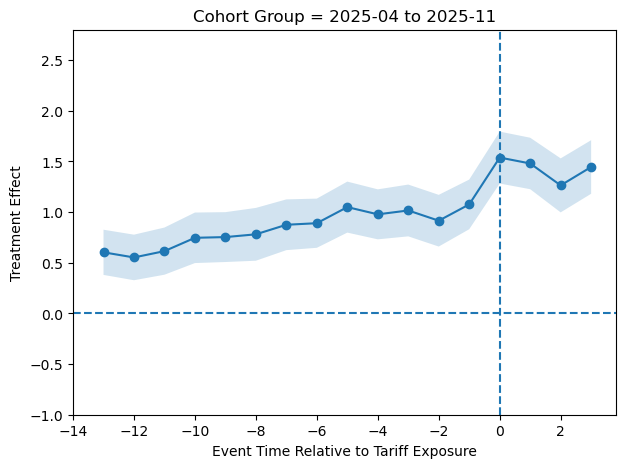

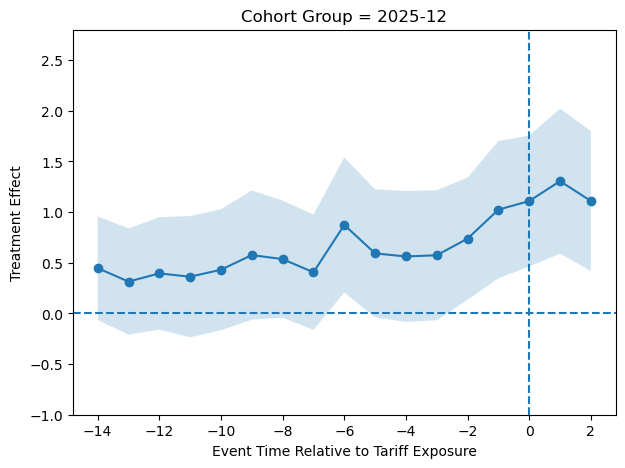

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/calendar2_1year_low


In [67]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low, ylim=LOW_YLIM)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")

In [68]:
# Change here !!!
match_method = "summary_4"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 68, Finished, Available, Finished, False)

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 69, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
697493  735999166200003220  2025-03  2023-01          0         -26   
697459  735999166200003220  2025-03  2023-02          0         -25   
697563  735999166200003220  2025-03  2023-03          0         -24   
697533  735999166200003220  2025-03  2023-11          0         -16   
697479  735999166200003220  2025-03  2023-12          0         -15   
...                    ...      ...      ...        ...         ...   
508049  735999166200013373  2025-03  2025-01          0          -2   
508070  735999166200013373  2025-03  2025-02          0          -1   
508091  735999166200013373  2025-03  2025-03          0           0   
508018  735999166200013373  2025-03  2025-11          0           8   
508021  735999166200013373  2025-03  2025-12          0           9   

        cohort_event_month  target_month_flag  new_event_time  
697493                   1                

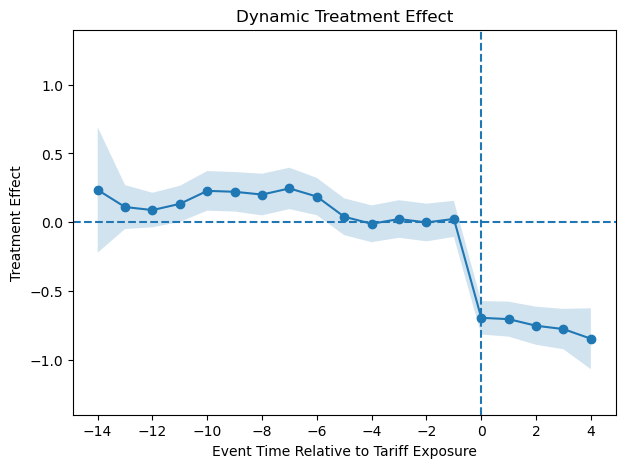


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.11491182399336079, 't_stat': 4.03947025969279, 'p_value': 0.0019502408385631553}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.7554555644150263, 'SE': 0.027459994653316413, 't_stat': -27.511132975540765, 'p_value': 0.0, 'CI_low': -0.8092771539355265, 'CI_high': -0.7016339748945261, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.7176462976656488, 'SE': 0.01782299005171623, 't_stat': -40.265202167721824, 'p_value': 0.0, 'CI_low': -0.7525793581670126, 'CI_high': -0.682713237164285, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  0.1343 0.1025  1.3112   0.1898        620   
1    2025-03             -11  0.2216 0.1059  2.0927   0.0364        620   
2    2025-03             -10  0.2829 0.1115  2.5379   0.0112        617   
3    2

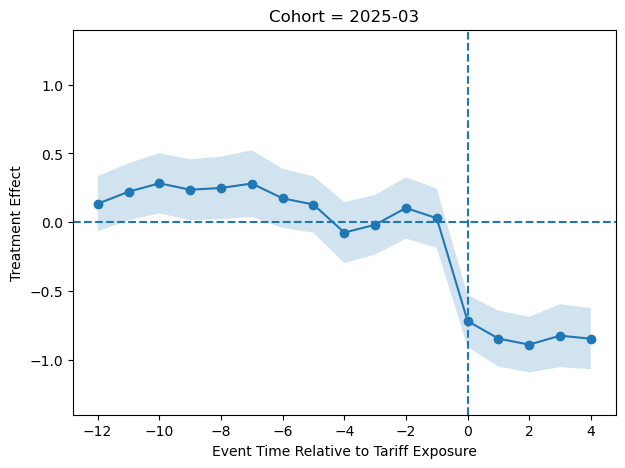

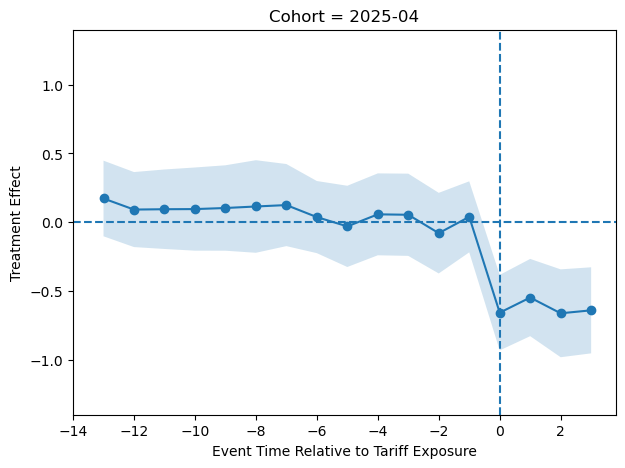

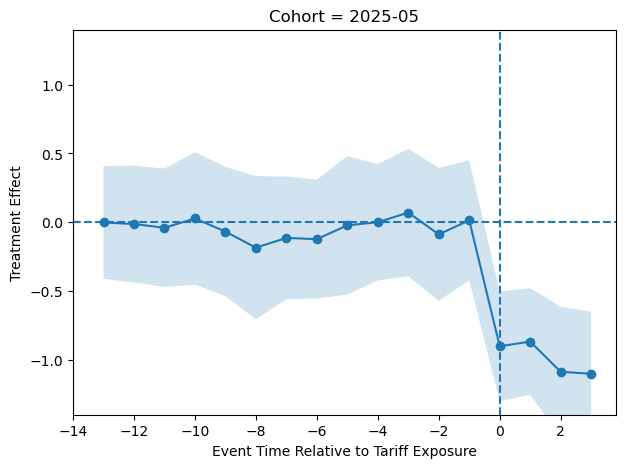

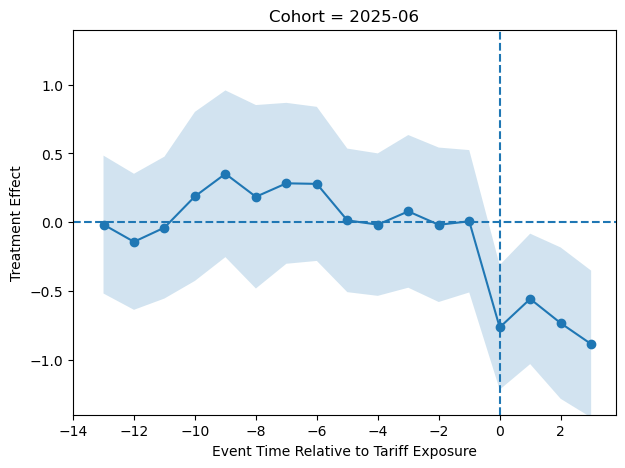

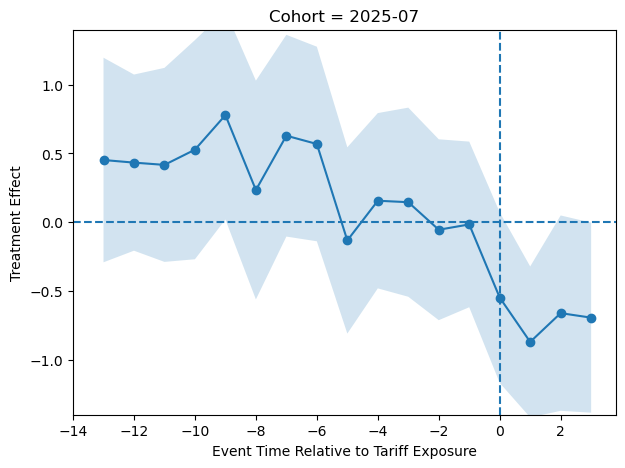

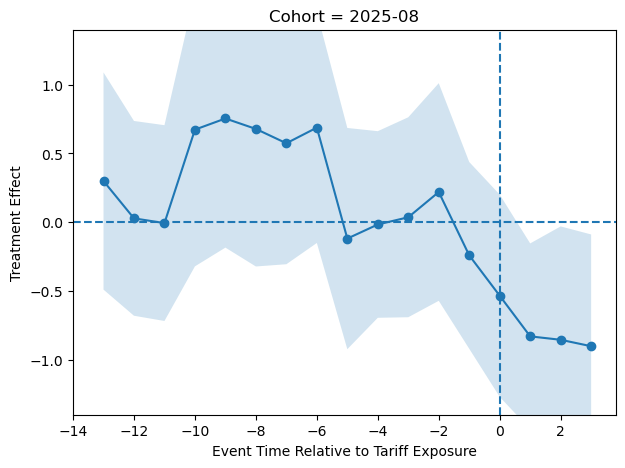

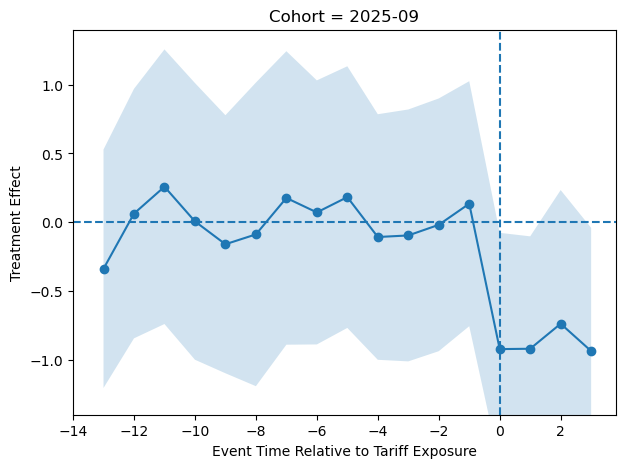

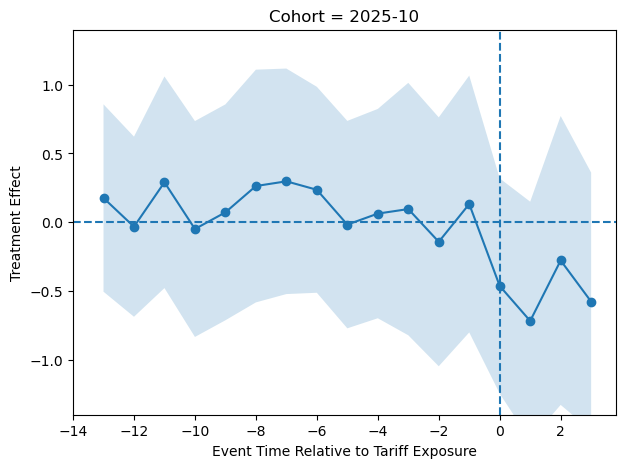

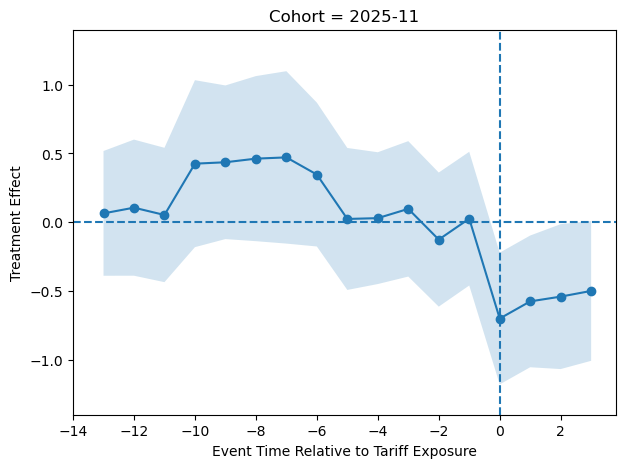

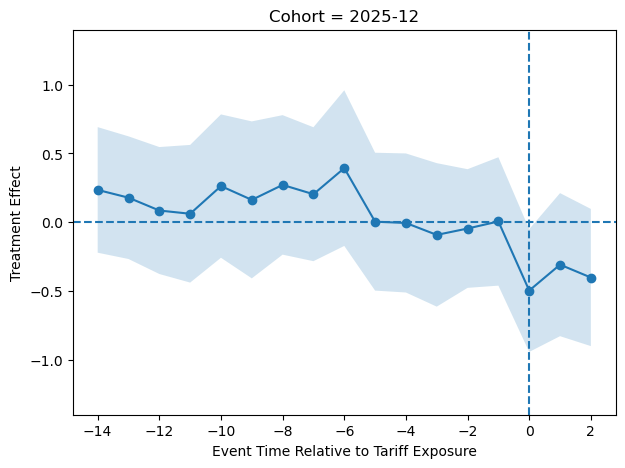

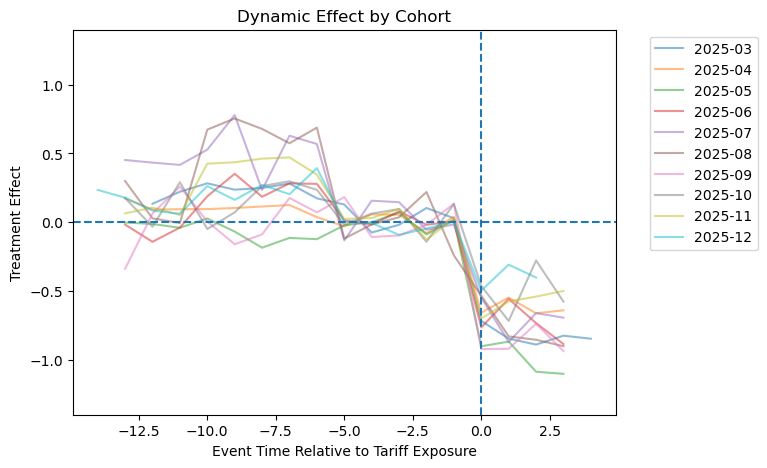


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8253 0.0288 -28.6387   0.0000 -0.8818  -0.7689          5
1  2025-04 -0.6272 0.0269 -23.3546   0.0000 -0.6798  -0.5745          4
2  2025-05 -0.9901 0.0611 -16.2088   0.0000 -1.1098  -0.8704          4
3  2025-06 -0.7356 0.0678 -10.8449   0.0000 -0.8686  -0.6027          4
4  2025-07 -0.6935 0.0668 -10.3799   0.0000 -0.8244  -0.5625          4
5  2025-08 -0.7804 0.0833  -9.3725   0.0000 -0.9436  -0.6172          4
6  2025-09 -0.8795 0.0473 -18.6135   0.0000 -0.9721  -0.7869          4
7  2025-10 -0.5093 0.0930  -5.4782   0.0000 -0.6915  -0.3271          4
8  2025-11 -0.5792 0.0433 -13.3694   0.0000 -0.6642  -0.4943          4
9  2025-12 -0.4026 0.0544  -7.3995   0.0000 -0.5092  -0.2959          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8181 0.0516 -15.8542   0.000

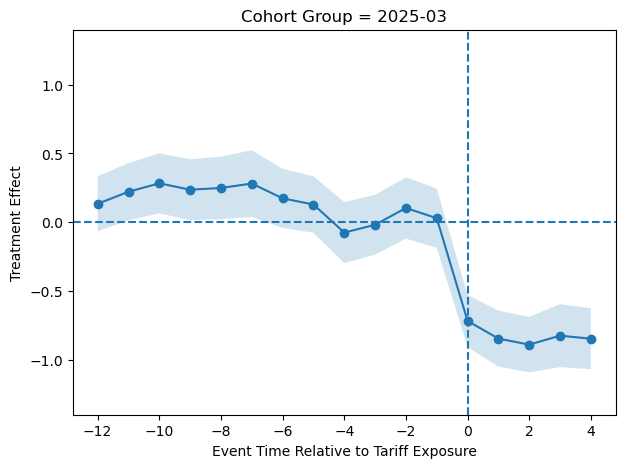

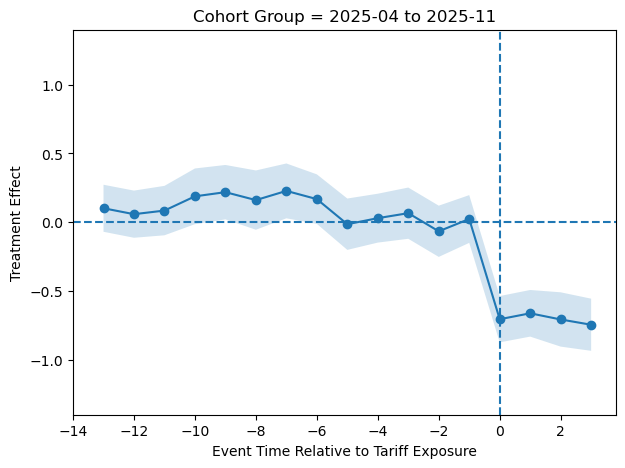

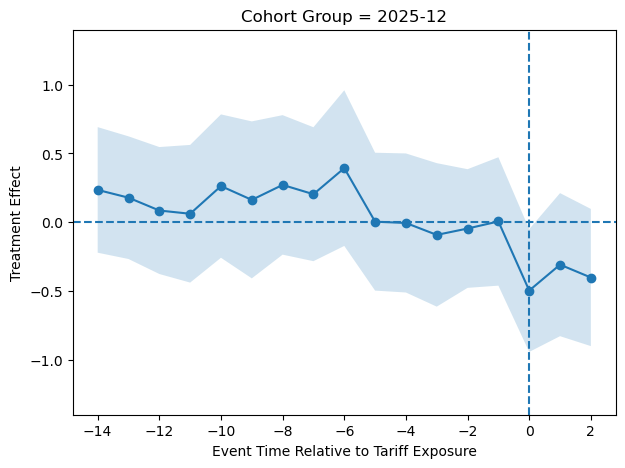

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/summary_4_high


In [69]:
df_high = df[df["price"]== "high"] 
results_high = run_full_analysis(df_high, ylim=HIGH_YLIM)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 70, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
697577  735999166200003220  2025-03  2023-01          0         -26   
697409  735999166200003220  2025-03  2023-02          0         -25   
697439  735999166200003220  2025-03  2023-03          0         -24   
697575  735999166200003220  2025-03  2023-04          0         -23   
697581  735999166200003220  2025-03  2023-05          0         -22   
...                    ...      ...      ...        ...         ...   
241644  735999166200004203  2025-03  2024-08          0          -7   
241641  735999166200004203  2025-03  2024-09          0          -6   
241626  735999166200004203  2025-03  2024-10          0          -5   
241658  735999166200004203  2025-03  2024-11          0          -4   
241628  735999166200004203  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
697577                   1                

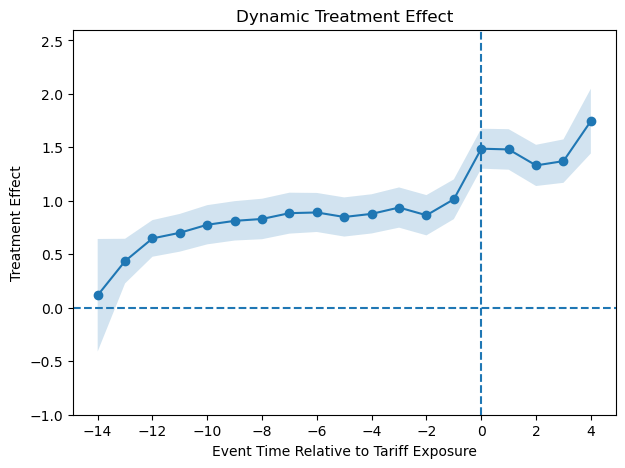


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.8408720038005519, 't_stat': 29.452155767241443, 'p_value': 8.146522214733064e-12}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.483313005090852, 'SE': 0.07227140009083921, 't_stat': 20.524204640098983, 'p_value': 0.0, 'CI_low': 1.3416610609128072, 'CI_high': 1.624964949268897, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.4331653702933398, 'SE': 0.05096942070517466, 't_stat': 28.118141239691152, 'p_value': 0.0, 'CI_low': 1.3332653057111974, 'CI_high': 1.5330654348754822, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.0778 0.1459  7.3890   0.0000        620   
1    2025-03             -11  1.1875 0.1502  7.9052   0.0000        620   
2    2025-03             -10  1.1523 0.1509  7.6339   0.0000        617   
3    2025-03   

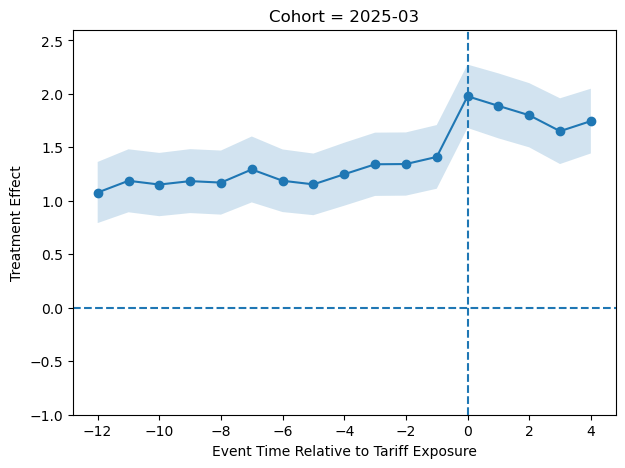

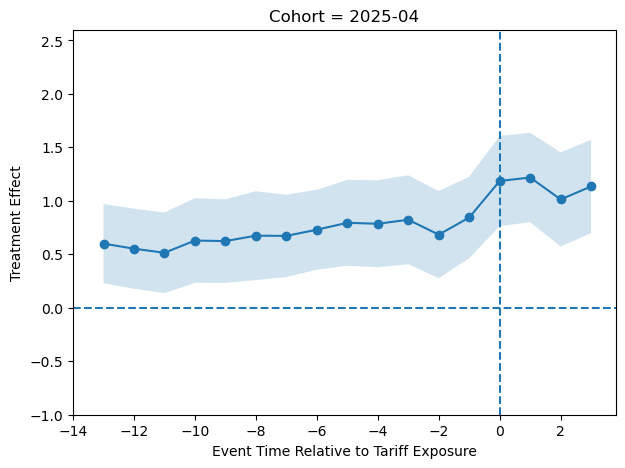

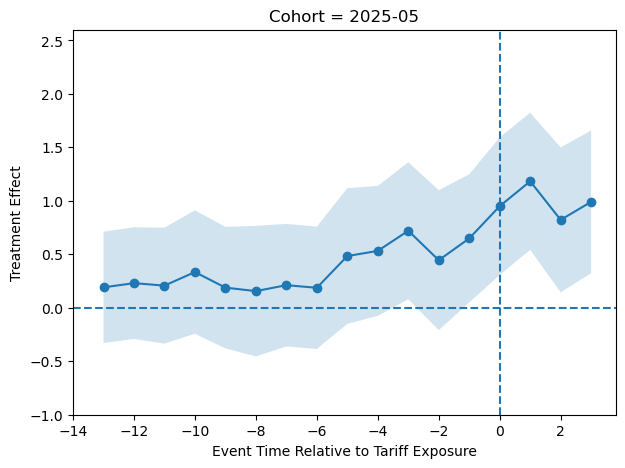

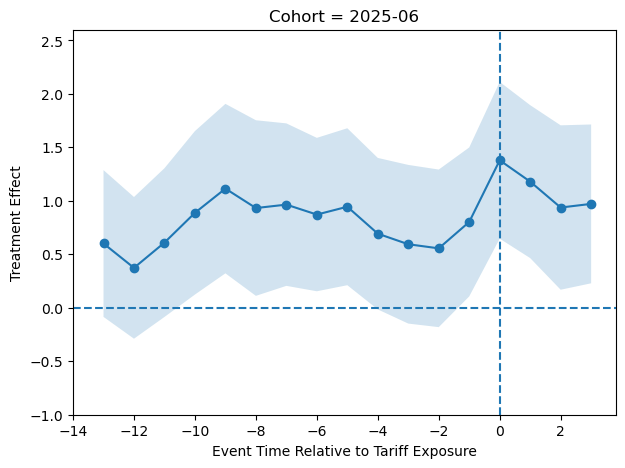

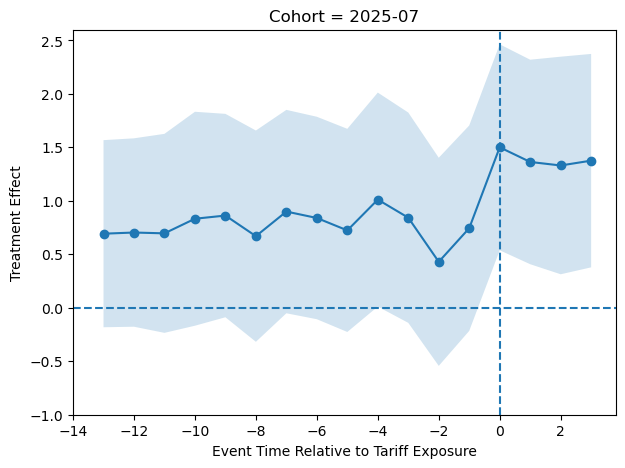

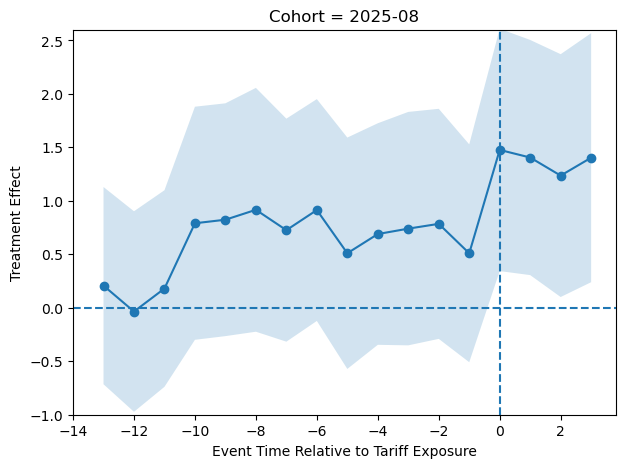

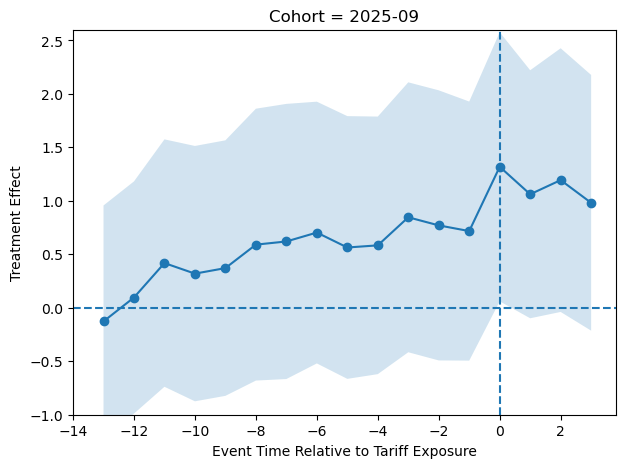

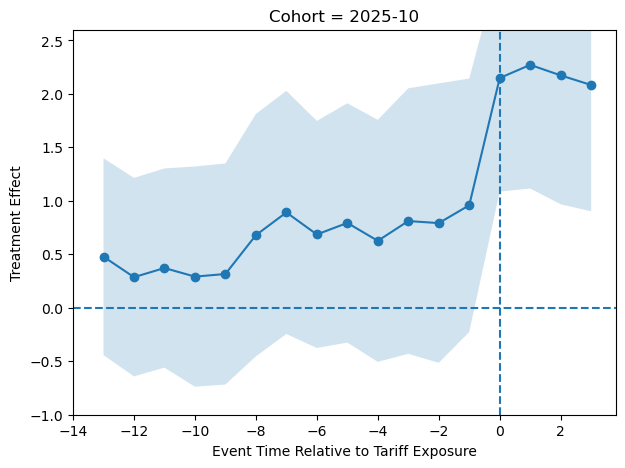

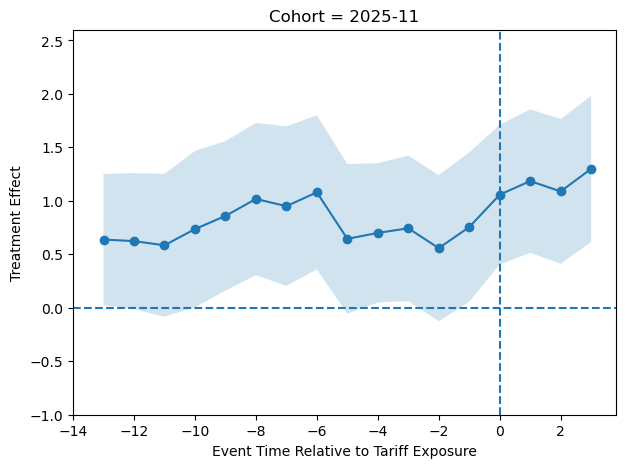

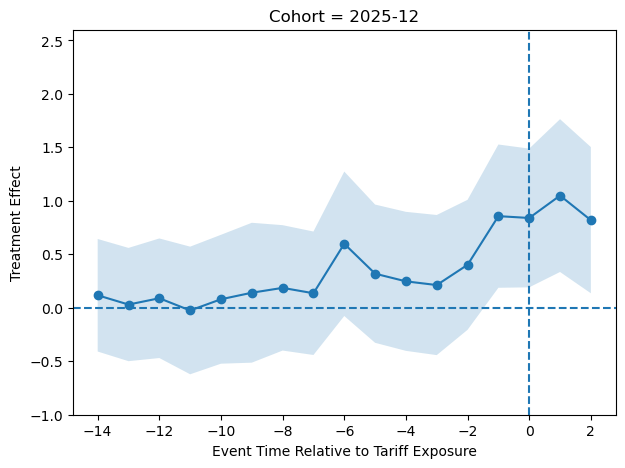

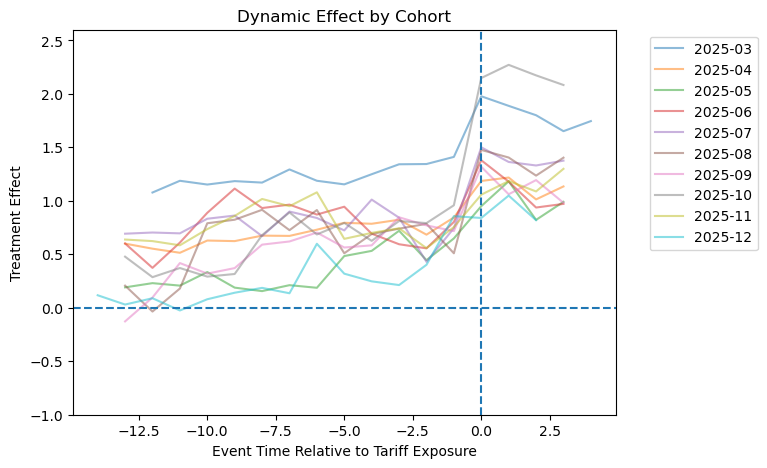


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.8127 0.0564 32.1476   0.0000  1.7021   1.9232          5
1  2025-04 1.1379 0.0449 25.3350   0.0000  1.0499   1.2260          4
2  2025-05 0.9864 0.0747 13.2071   0.0000  0.8400   1.1328          4
3  2025-06 1.1169 0.1025 10.8950   0.0000  0.9160   1.3178          4
4  2025-07 1.3926 0.0372 37.4107   0.0000  1.3197   1.4656          4
5  2025-08 1.3801 0.0510 27.0698   0.0000  1.2802   1.4800          4
6  2025-09 1.1388 0.0742 15.3474   0.0000  0.9934   1.2842          4
7  2025-10 2.1691 0.0391 55.4955   0.0000  2.0925   2.2457          4
8  2025-11 1.1573 0.0545 21.2281   0.0000  1.0505   1.2642          4
9  2025-12 0.9026 0.0735 12.2823   0.0000  0.7586   1.0467          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.8888 0.0512 36.9014   0.0000  1.7884   1.9891        

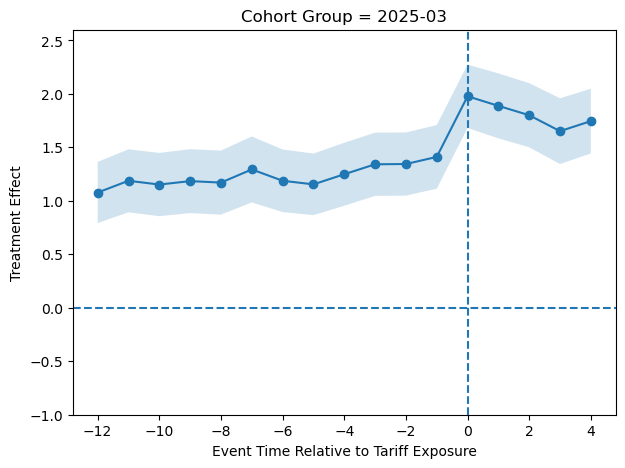

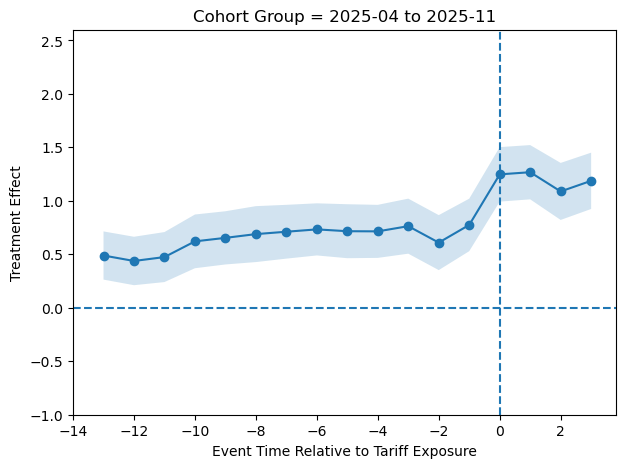

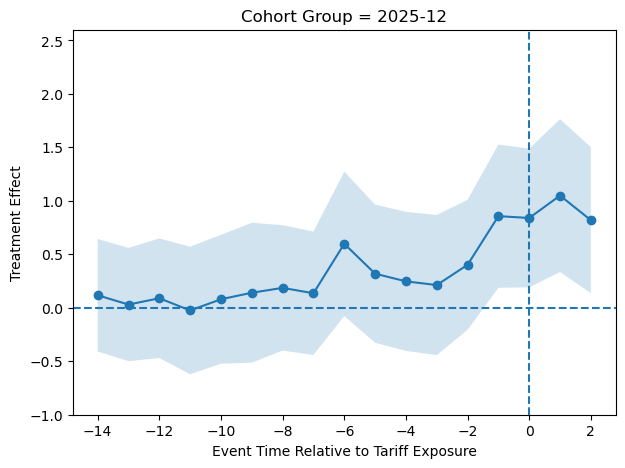

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/summary_4_all


In [70]:
df_all = df[df["price"]== "all"] 
run_full_analysis(df_all, ylim=ALL_YLIM)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, f2c4bf35-fba0-4a72-b781-d7b9024fcefe, 71, Finished, Available, Finished, False)


===== TRANSFORMED EVENT TIME DATA =====
                       aID   cohort TIDPUNKT  treatment  event_time  \
697497  735999166200003220  2025-03  2023-01          0         -26   
697465  735999166200003220  2025-03  2023-02          0         -25   
697411  735999166200003220  2025-03  2023-03          0         -24   
697489  735999166200003220  2025-03  2023-04          0         -23   
697481  735999166200003220  2025-03  2023-05          0         -22   
...                    ...      ...      ...        ...         ...   
241689  735999166200004203  2025-03  2024-08          0          -7   
241690  735999166200004203  2025-03  2024-09          0          -6   
241627  735999166200004203  2025-03  2024-10          0          -5   
241619  735999166200004203  2025-03  2024-11          0          -4   
241691  735999166200004203  2025-03  2024-12          0          -3   

        cohort_event_month  target_month_flag  new_event_time  
697497                   1                

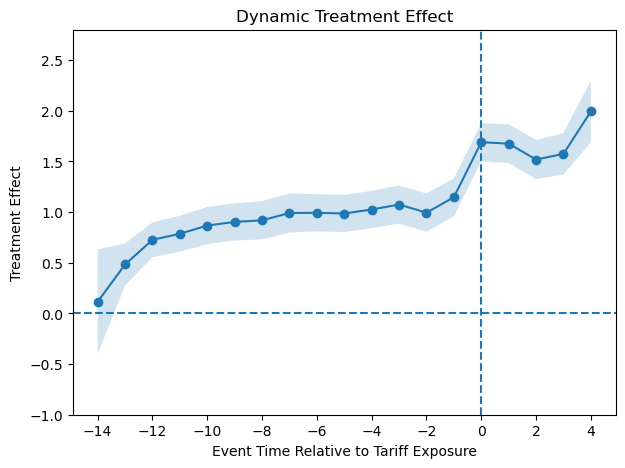


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.9509931574182321, 't_stat': 27.9158987849086, 'p_value': 1.4580477453476364e-11}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.6903812931797657, 'SE': 0.08214254923118097, 't_stat': 20.57863201228851, 'p_value': 0.0, 'CI_low': 1.529381896686651, 'CI_high': 1.8513806896728804, 'n_periods': 5}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.6278747962443132, 'SE': 0.054887386426543026, 't_stat': 29.658449822946718, 'p_value': 0.0, 'CI_low': 1.520295518848289, 'CI_high': 1.7354540736403374, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  new_event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03             -12  1.1902 0.1465  8.1263   0.0000        620   
1    2025-03             -11  1.3033 0.1509  8.6370   0.0000        620   
2    2025-03             -10  1.2979 0.1524  8.5154   0.0000        617   
3    2025-03    

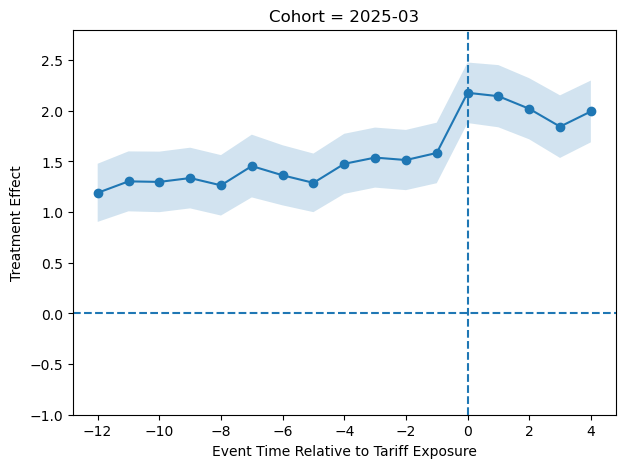

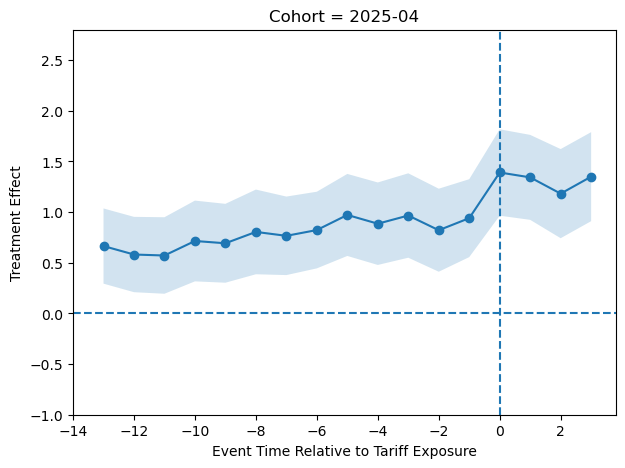

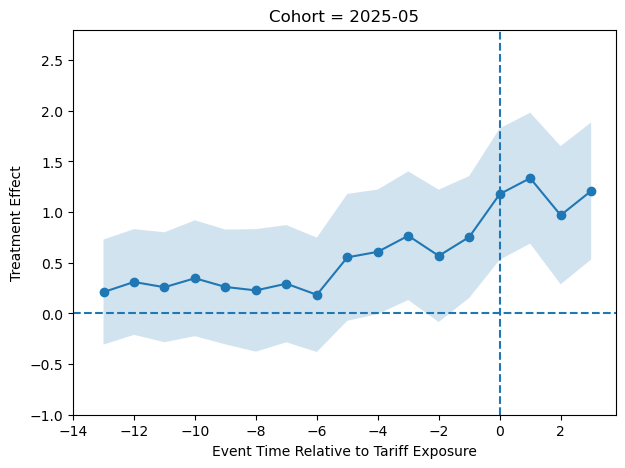

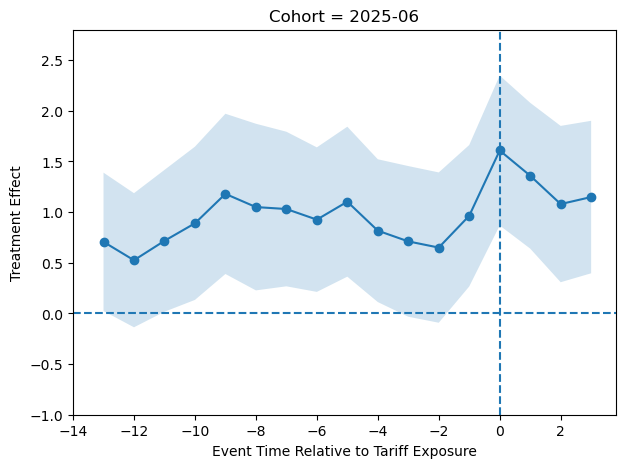

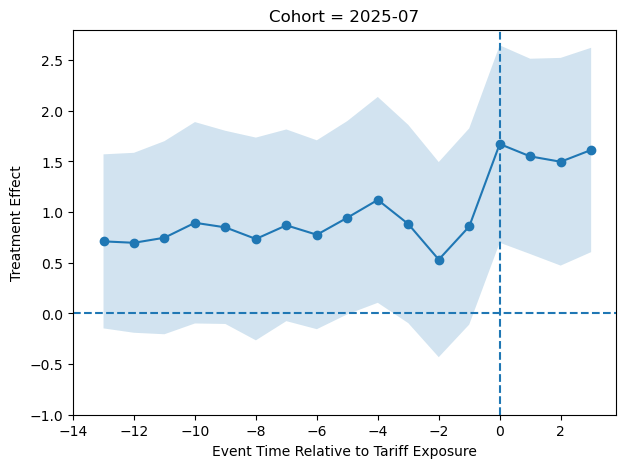

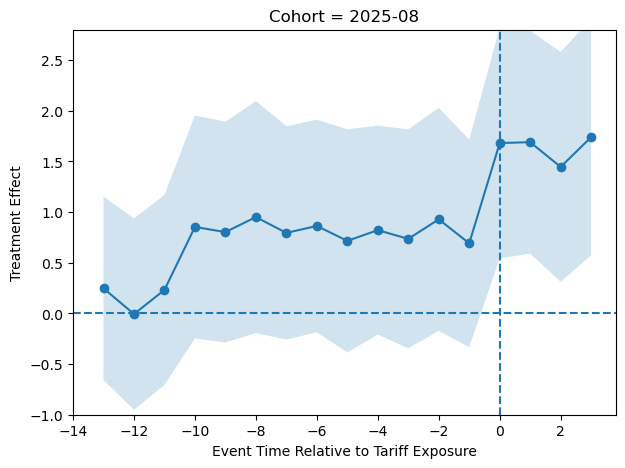

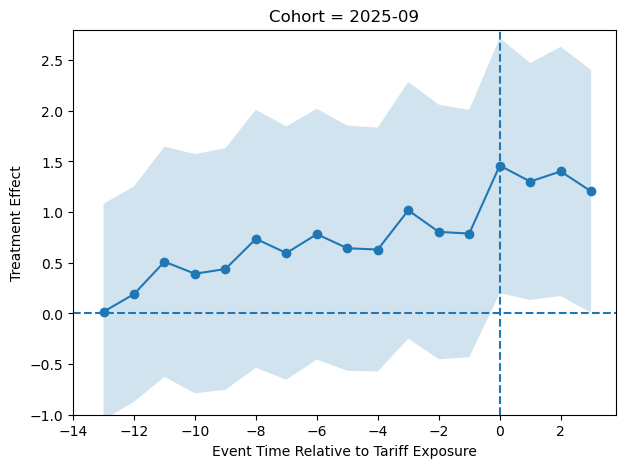

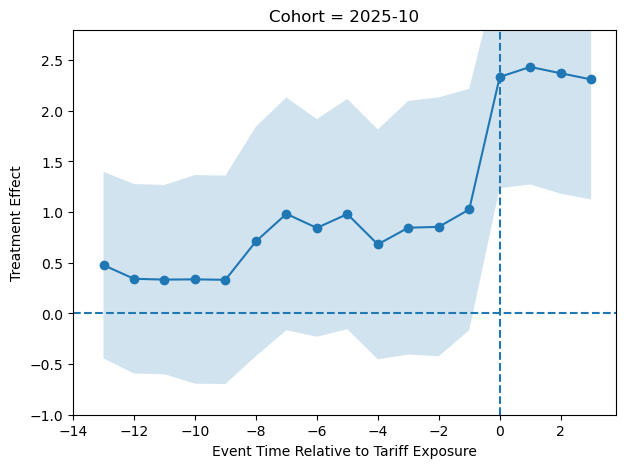

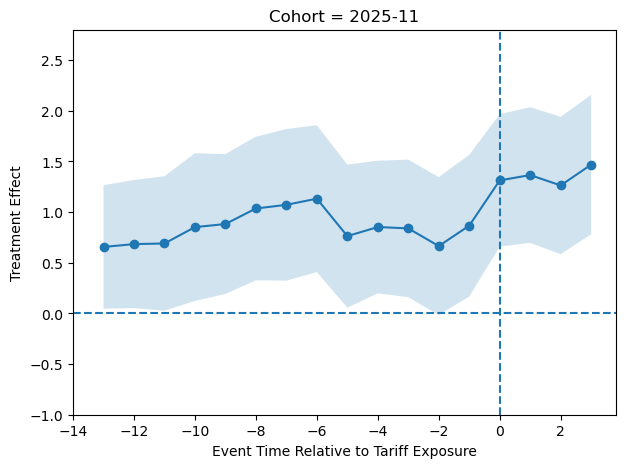

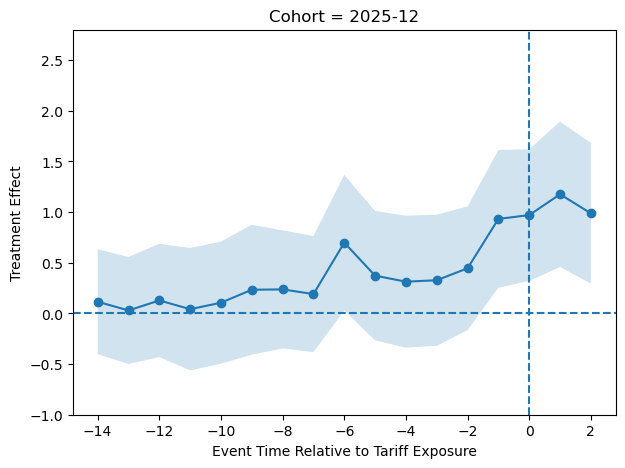

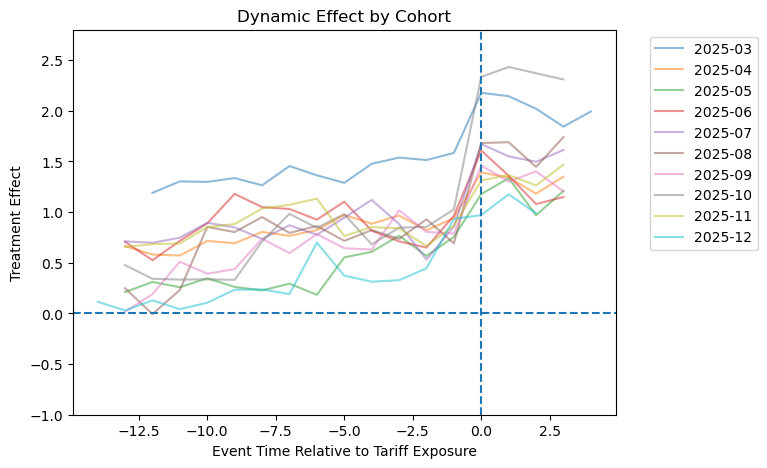


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.0357 0.0595 34.2041   0.0000  1.9190   2.1523          5
1  2025-04 1.3163 0.0460 28.6264   0.0000  1.2262   1.4065          4
2  2025-05 1.1726 0.0759 15.4520   0.0000  1.0239   1.3213          4
3  2025-06 1.2987 0.1190 10.9106   0.0000  1.0654   1.5320          4
4  2025-07 1.5830 0.0380 41.6422   0.0000  1.5085   1.6575          4
5  2025-08 1.6393 0.0657 24.9501   0.0000  1.5105   1.7680          4
6  2025-09 1.3418 0.0562 23.8553   0.0000  1.2316   1.4521          4
7  2025-10 2.3617 0.0267 88.3537   0.0000  2.3093   2.4141          4
8  2025-11 1.3524 0.0439 30.8013   0.0000  1.2664   1.4385          4
9  2025-12 1.0447 0.0659 15.8553   0.0000  0.9155   1.1738          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.1138 0.0479 44.1101   0.0000  2.0199   2.2077        

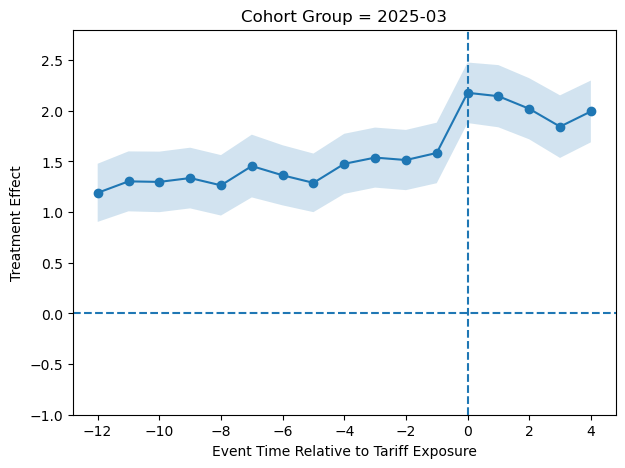

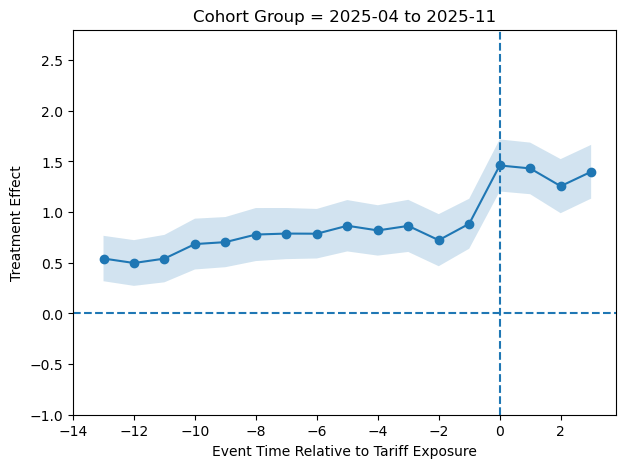

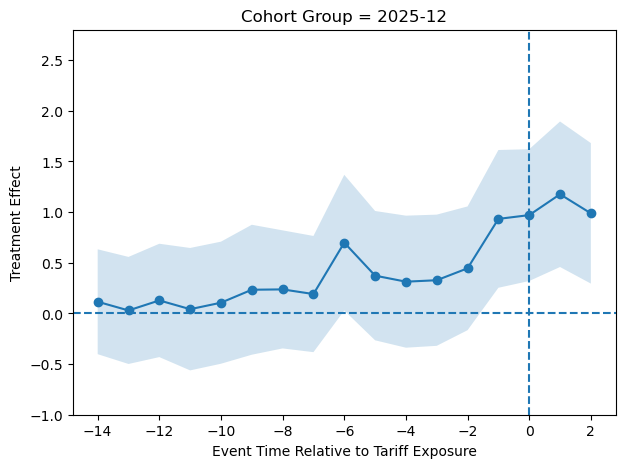

✅ Results saved to: /lakehouse/default/Files/output/inference/matching_high/summary_4_low


In [71]:
df_low = df[df["price"]== "low"] 
run_full_analysis(df_low, ylim=LOW_YLIM)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")